In [19]:
## This version of 1D greedy algorithm, the numerical quadrature used for assembling the linear system is consistent with 
## the quadrature used for the argmax subproblem.
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
import scipy
import math 
from scipy.sparse import linalg
from pathlib import Path
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 


pi = torch.tensor(np.pi,dtype=torch.float64)
torch.set_default_dtype(torch.float64)

class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1

class model_tanh(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
    def forward(self, x):
        u1 = self.fc2(torch.tanh(self.fc1(x)))
        return u1

class model_cosine(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1, bias = False)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
    def forward(self, x):
        u1 = self.fc2(torch.cos(2 * pi * self.fc1(x)))
        return u1
    

def PiecewiseGQ2D_weights_points(Nx, order,l_point = (-1,-1), r_point = (1,1)): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters. 
    Only works for the square domain centered at origin or with the left point at origin.
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    l_point: (x1,x2)
        left bottom point of the rectangular domain 
    r_point: (x1,x2)
        right top point of the rectangular domain 

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
    assert Nx%2==0, "Nx should be even" 

    h1 = (r_point[0] - l_point[0])/Nx
    h2 = (r_point[1] - l_point[1])/Nx 

    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * (h1/2) * (h2/2) # scale the weights  
    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h1/2 
    integration_points = scale_factor * integration_points

    offset = 0 if l_point[0] == 0 else 1 

    index = np.arange(1,Nx+1)- (Nx/2)*offset - 0.5 
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T
    ordered_pairs = torch.tensor(ordered_pairs)
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    ordered_pairs =  ordered_pairs.reshape(-1,2)

    translation = ordered_pairs*h1
    integration_points = integration_points + translation 
    return long_weights, integration_points


In [ ]:

def initialize_uniform(my_model,target = None):
    """
    mutator function. input: my_model
    """
    #FEM initialization
    neuron_number = my_model.fc1.bias.size(0)
    h = 2*1/neuron_number
    #wi(x-x_i)
    wi = torch.full((neuron_number,1),1/h)
    bi = torch.linspace(-1,1,neuron_number + 1)[:-1].view(neuron_number,1) #x_i
    bi = -(wi*bi).view(neuron_number)
    my_model.fc1.weight.data = wi # somehow this local variable is not destroyed
    my_model.fc1.bias.data = bi
    return my_model 
    
def initialize_w_b_uniform(my_model,R_m): # mostly used in ELM 
    nn.init.uniform_(my_model.fc1.weight, a = -R_m, b = R_m)
    nn.init.uniform_(my_model.fc1.bias, a = -R_m, b = R_m)
    return my_model 


def initialize_w_sphere_b_uniform(my_model,R_m): 
    # nn.init.uniform_(my_model.fc1.weight, a = -R_m, b = R_m)
    # initialize the weights to be on the sphere 
    # decide dimension of the sphere 
    w = my_model.fc1.weight
    b = my_model.fc1.bias
    out_feats, in_feats = w.shape
    device = w.device
    # dtype = w.dtype
    with torch.no_grad():
        if in_feats == 1:  #n by 1 
            ones = torch.ones(out_feats,1).to(device)
            w[:,:]=  ones[:,:]
        elif in_feats == 2: # omega uniform grid on S^1
            theta = np.linspace(0,2*pi,out_feats,endpoint=False) 
            theta = torch.tensor(theta).to(device)
            w[:, 0] = theta.cos()
            w[:, 1] = theta.sin()
        elif in_feats == 3:# omega uniform grid on S^2 

            indices = torch.arange(0, out_feats, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/out_feats)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            points = torch.stack((x, y, z), dim=1)
            w[:,:] = points[:,0:3]

        elif in_feats >= 4: 
            nn.init.normal_(w, mean = 0, std = 1)
            w[:,:] = w[:,:] / torch.norm(w,dim=1).view(-1,1) 

            
        biases = torch.linspace(-R_m,R_m,my_model.fc1.bias.size(0)) # 
        my_model.fc1.bias.data[:] = biases[:]

    return my_model

def initialize_w_b_sphere(my_model,R_m):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 
    out_feats, in_feats = my_model.fc1.weight.shape 
    if in_feats == 2: 
        indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
        phi = torch.acos(1 - 2*indices/neuron_nums)
        theta = pi * (1 + 5**0.5) * indices
        x = torch.sin(phi) * torch.cos(theta)
        y = torch.sin(phi) * torch.sin(theta)
        z = torch.cos(phi)

        points = torch.stack((x, y, z), dim=1)
        my_model.fc1.weight.data[:,:] = points[:,0:2] * R_m
        my_model.fc1.bias.data[:] = points[:,2] * R_m 
    else: 
        w_b = torch.randn(neuron_nums,in_feats + 1) 
        w_b = w_b / torch.norm(w_b,dim=1).view(-1,1) 
        w_b = w_b * R_m 
        my_model.fc1.weight.data[:,:] = w_b[:,:-1] 
        my_model.fc1.bias.data[:] = w_b[:,-1] 
    return my_model 

def initialize_w_b_petrushev(my_model,R_m):
    w = my_model.fc1.weight
    b = my_model.fc1.bias
    out_feats, in_feats = w.shape
    device = w.device
    n1 = math.ceil(out_feats**((in_feats - 1)/in_feats))
    n2 = math.ceil(out_feats**(1/in_feats))
    with torch.no_grad():
        if in_feats == 1:  #n by 1 
            weights = torch.ones(n1,1).to(device)
            weights[:,0] = torch.linspace(-R_m,R_m,n1) 
        elif in_feats == 2:
            weights = torch.zeros(n1,2).to(device)
            theta = np.linspace(0,2*pi,n1,endpoint=False) 
            theta = torch.tensor(theta).to(device)
            weights[:, 0] = theta.cos()
            weights[:, 1] = theta.sin() 
            #form a tensor product of weights and biases
        elif in_feats == 3: 
            indices = torch.arange(0, n1, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/n1)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            weights = torch.stack((x, y, z), dim=1)
        elif in_feats >= 4: 
            # nn.init.normal_(w, mean = 0, std = 1)
            weights = torch.randn(n1, in_feats).to(device) 
            weights = weights / torch.norm(weights,dim=1).view(-1,1) 

        # form a tensor product of weights and biases 
        weights = torch.tile(weights, (1,n2)).reshape(-1,in_feats) 
        # print("weights shape: ", weights.shape) 
        # print("nn w shape: ", w.shape)
        my_model = model_tanh(in_feats, n1*n2, 1).to(device) 
        biases = torch.linspace(-R_m,R_m,n2)
        biases = torch.tensor(biases).to(device) 
        biases = torch.tile(biases, (n1,1)).reshape(-1) 
        # w[:,:] = weights[:out_feats,:] 
        my_model.fc1.weight.data[:,:] = weights[:,:]
        my_model.fc1.bias.data[:] = biases[:] 

    return my_model 


In [3]:
def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    in_feat, out_feat = model.fc1.weight.shape 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = torch.tanh(Z)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs


def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        ## change 
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f 

## 2D scheme 1. 

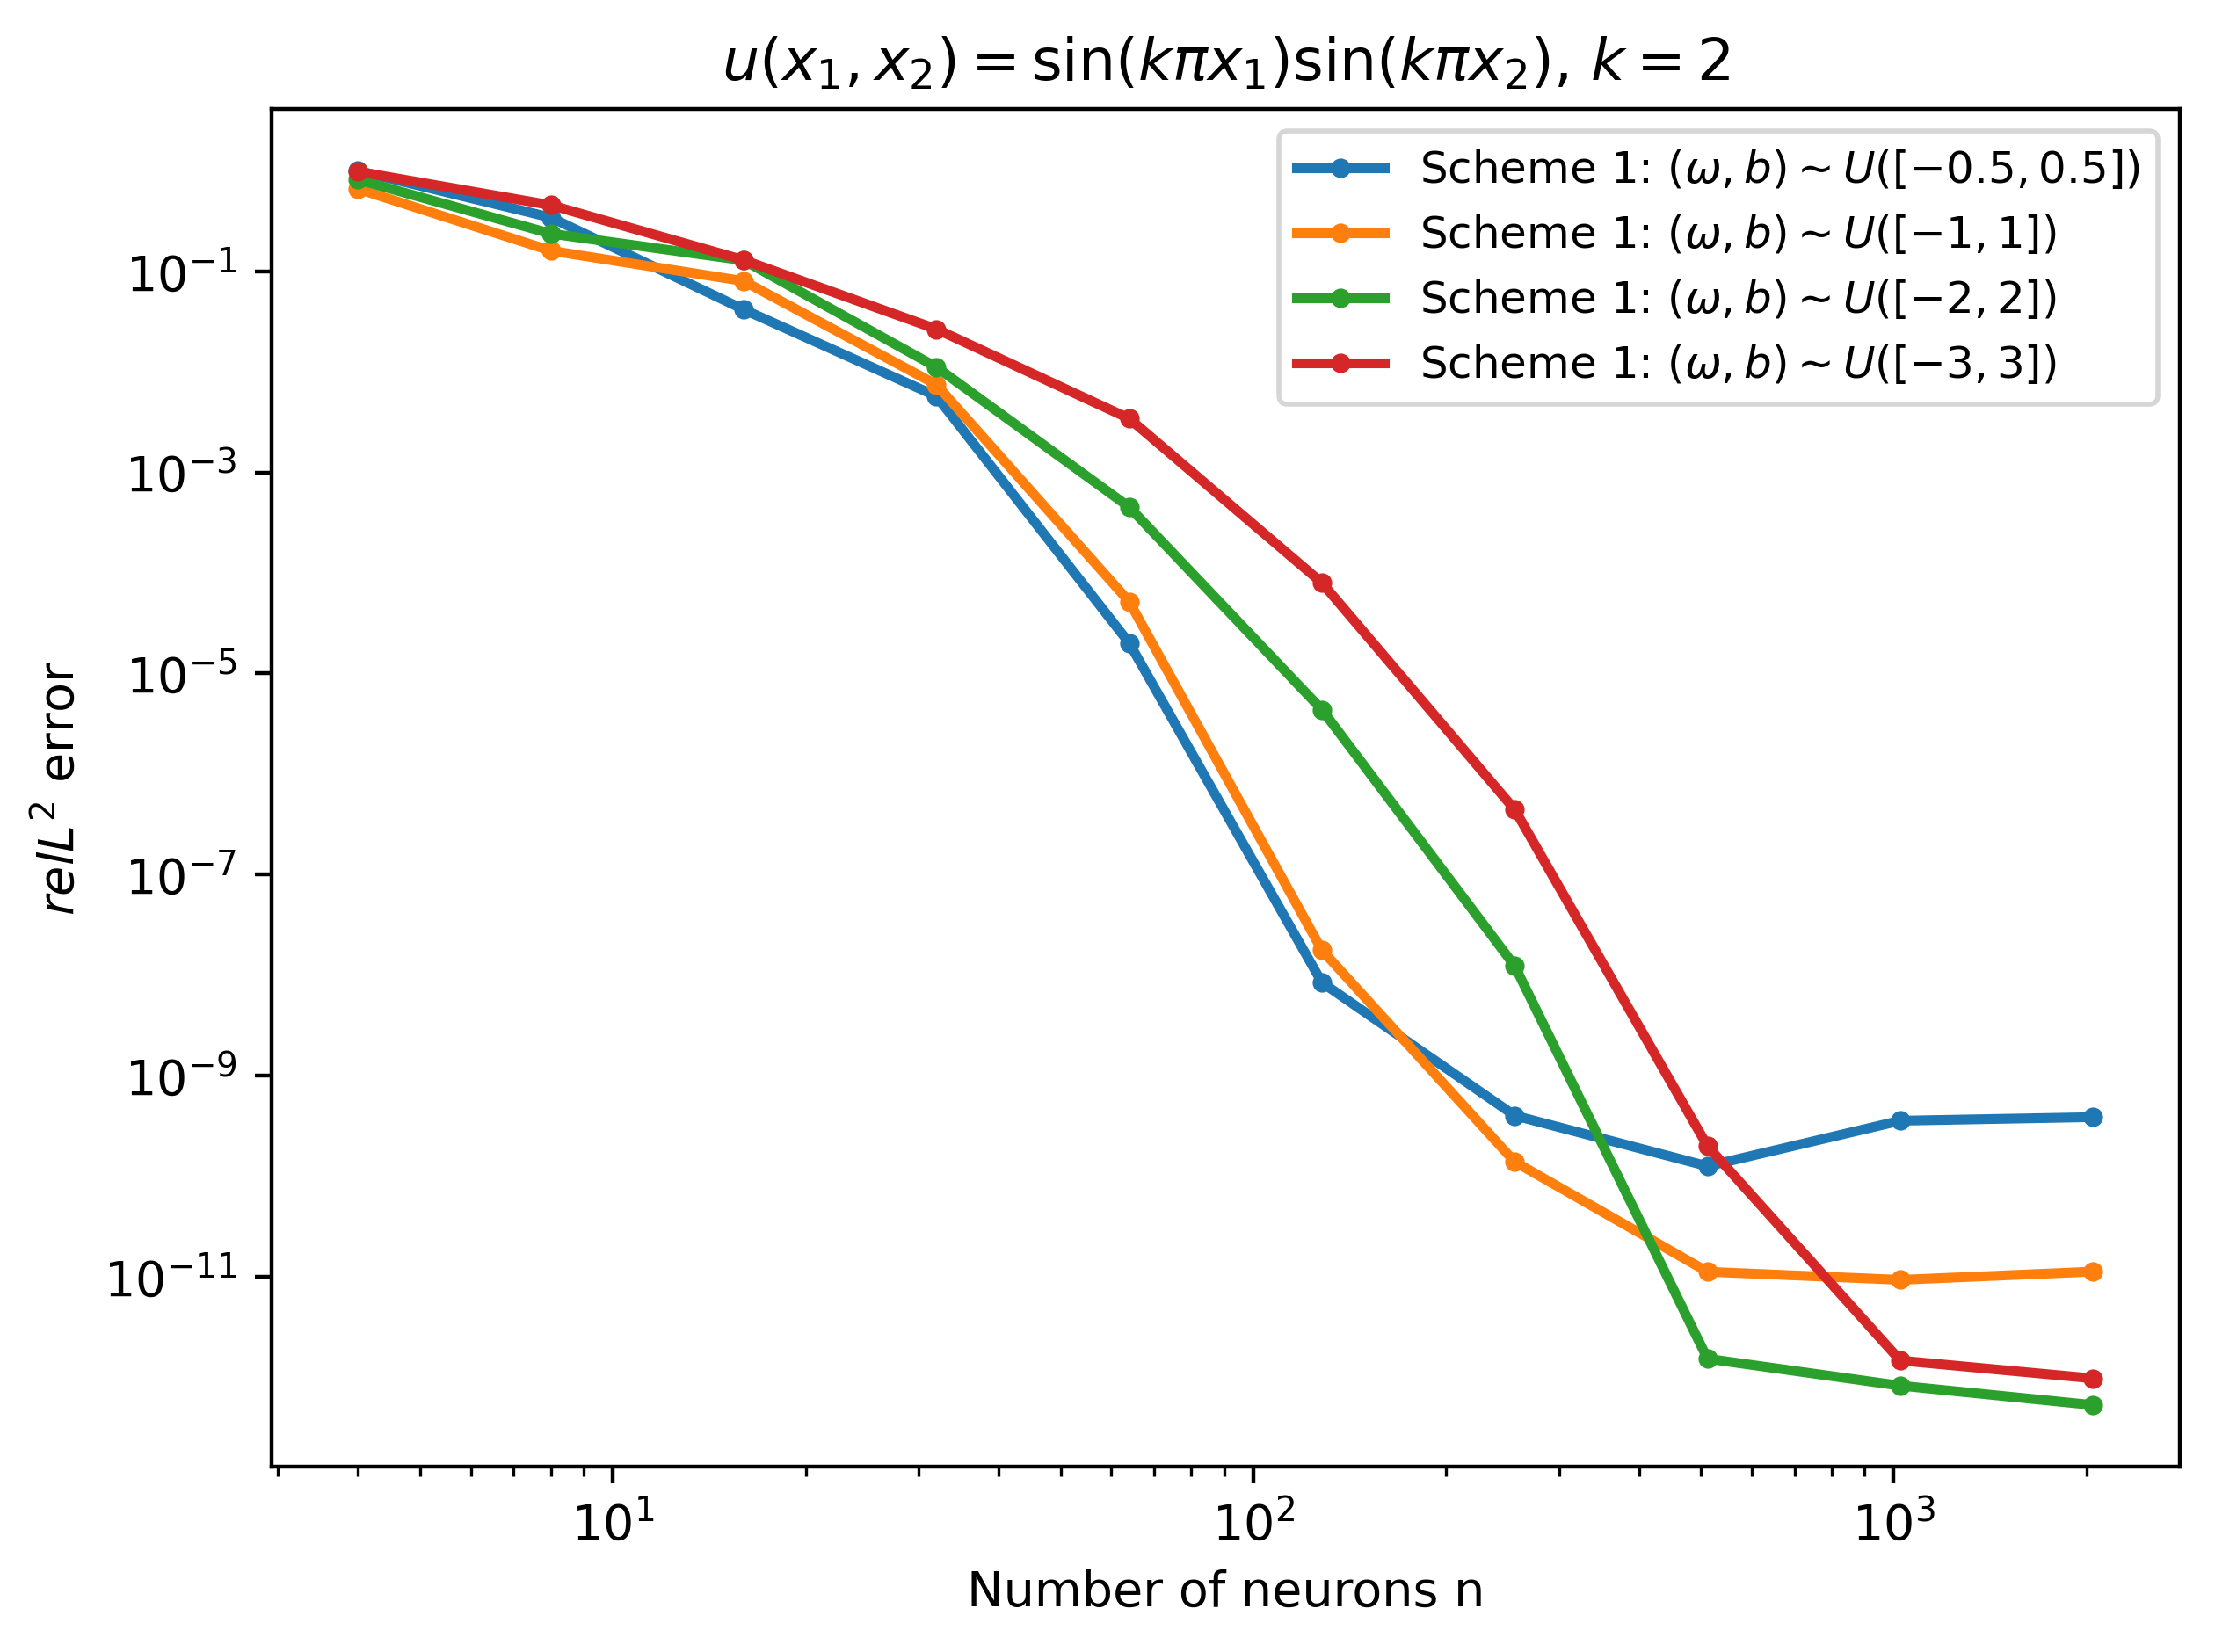

In [ ]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 2 
def target(x):
    z =  torch.sin(k*x[:,0:1])*torch.sin(k*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,50)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [0.5,1,2,3]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    # plt.figure(dpi = 400)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    # log_M = np.log(neuron_num_arr)
    # log_errors = np.log(mean_err_l2_arr)
    # slope, intercept = np.polyfit(log_M, log_errors, 1)
    # def line_of_best_fit(x):
    #     return np.exp(intercept) * (x ** slope)
    # best_fit = line_of_best_fit(neuron_num_arr)
    # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

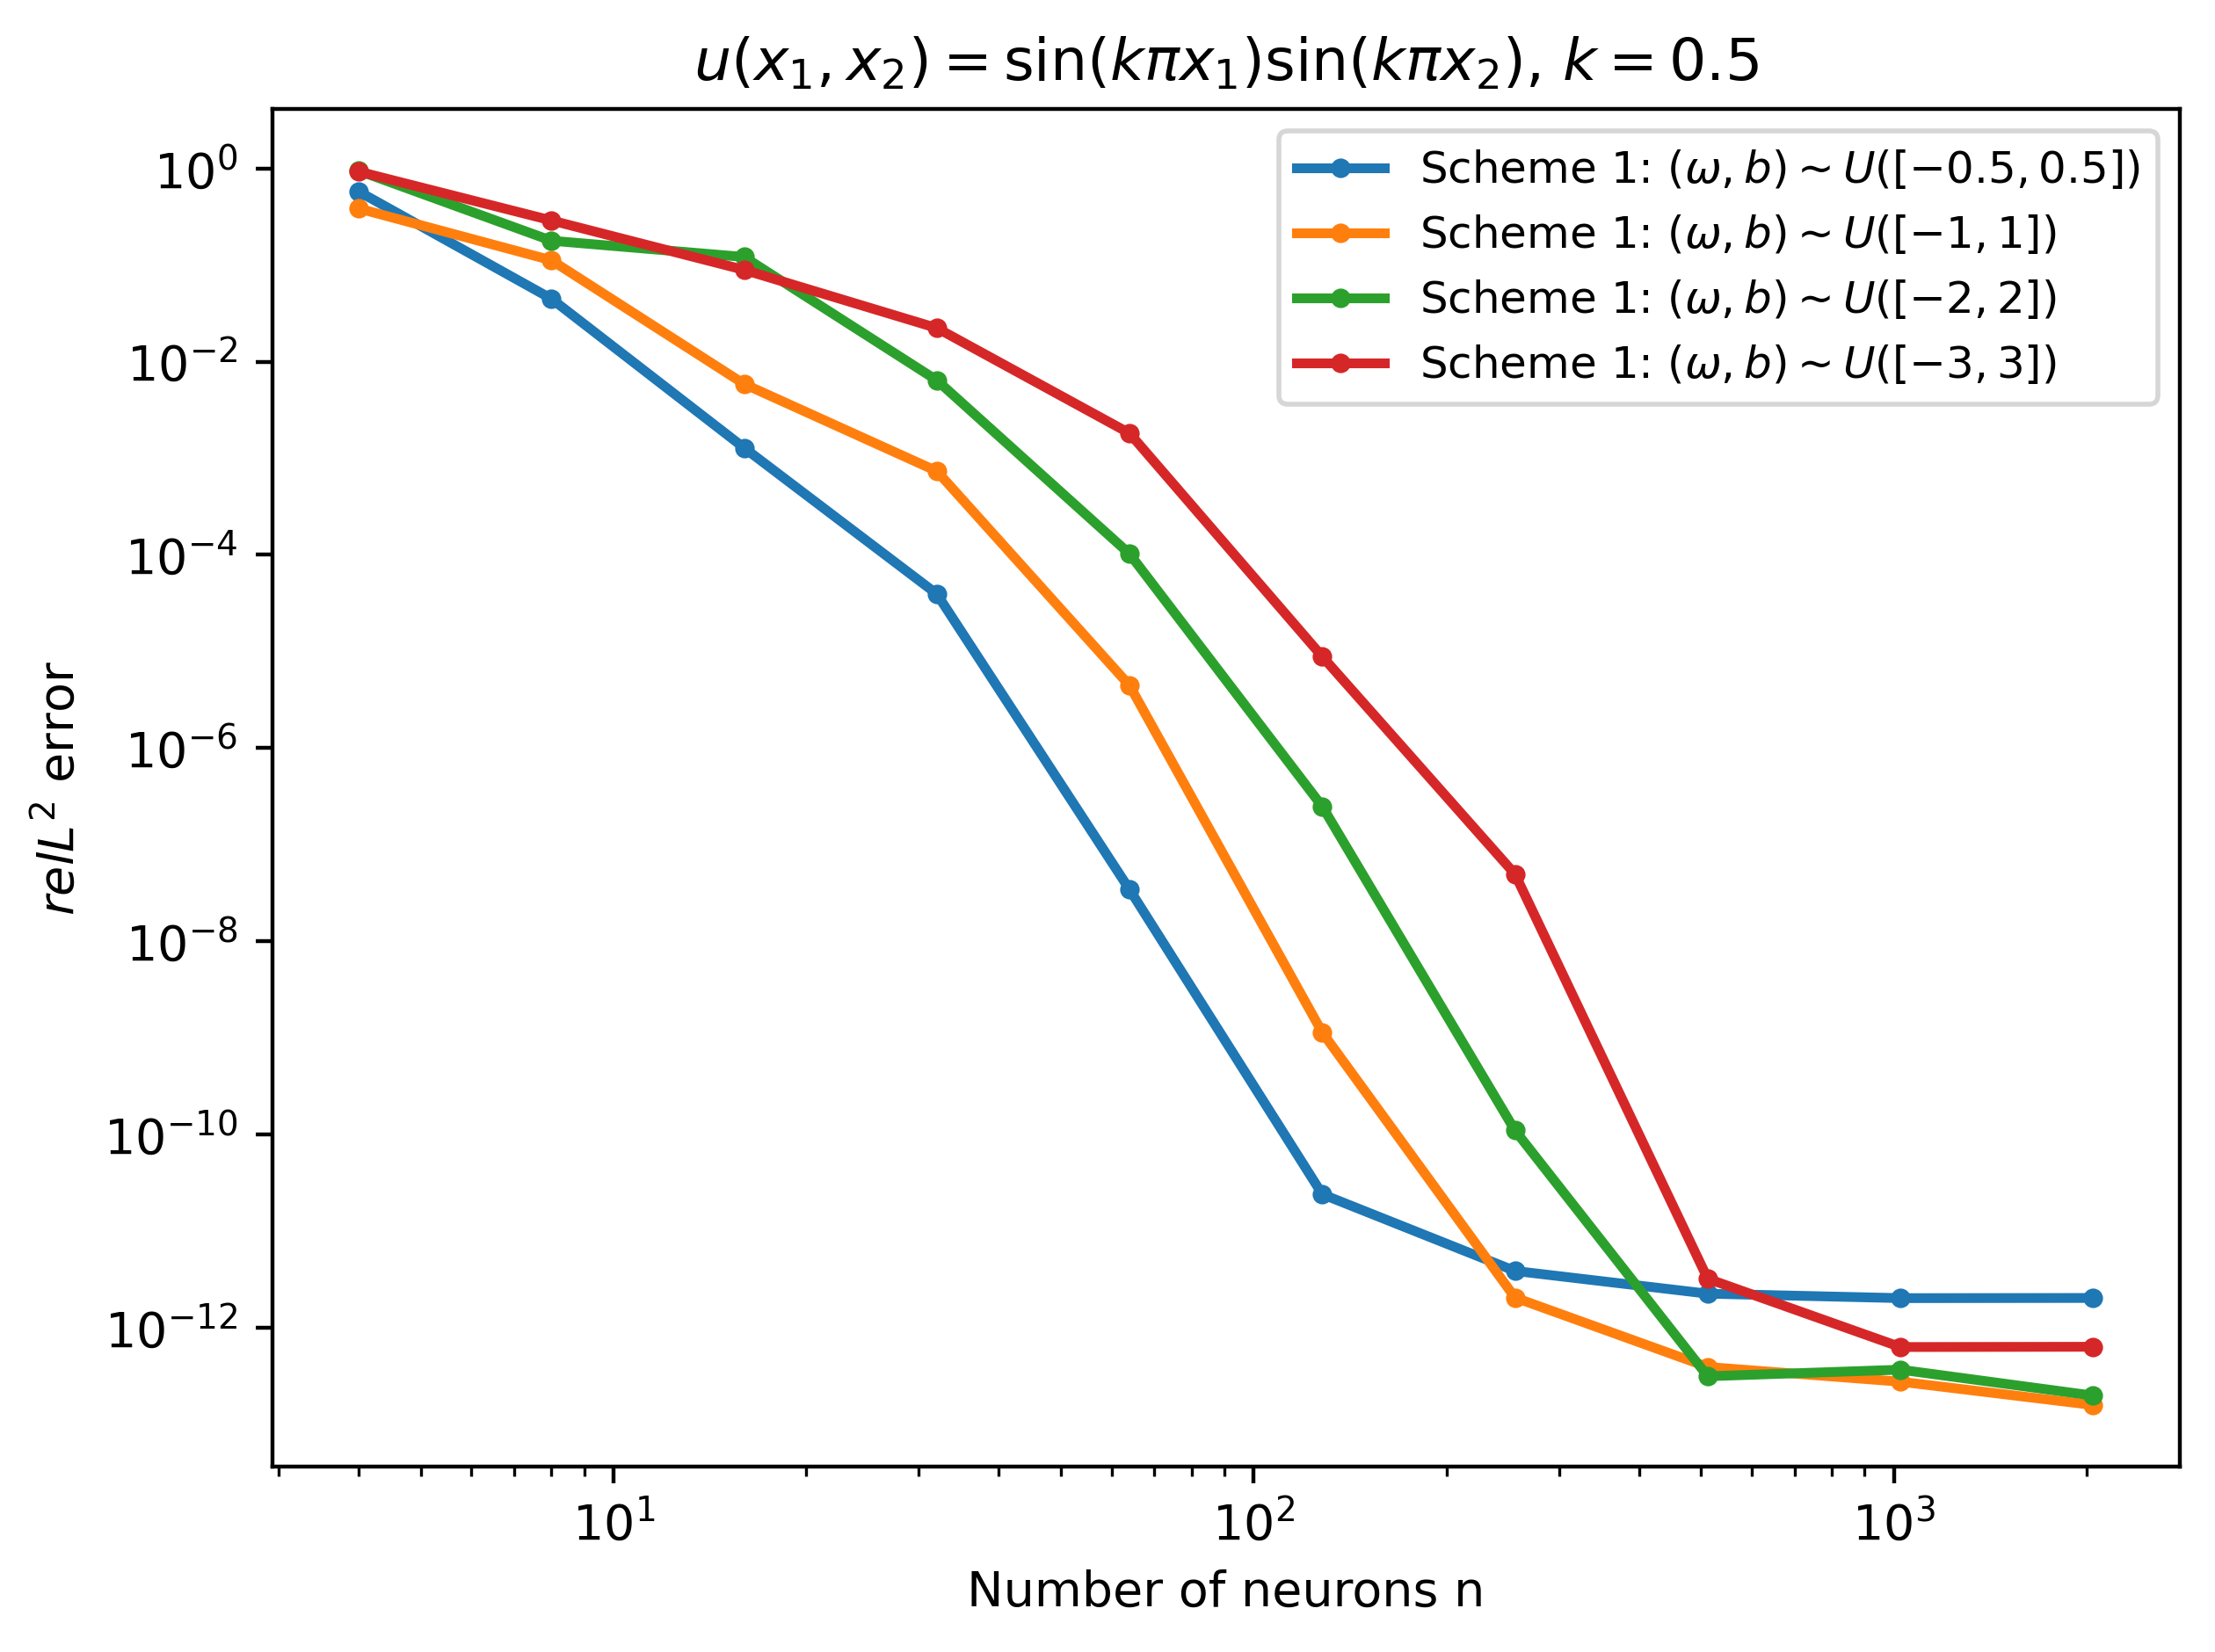

In [5]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 0.5  
def target(x):
    z =  torch.sin(k*x[:,0:1])*torch.sin(k*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,50)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [0.5,1,2,3]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    # plt.figure(dpi = 400)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    # log_M = np.log(neuron_num_arr)
    # log_errors = np.log(mean_err_l2_arr)
    # slope, intercept = np.polyfit(log_M, log_errors, 1)
    # def line_of_best_fit(x):
    #     return np.exp(intercept) * (x ** slope)
    # best_fit = line_of_best_fit(neuron_num_arr)
    # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

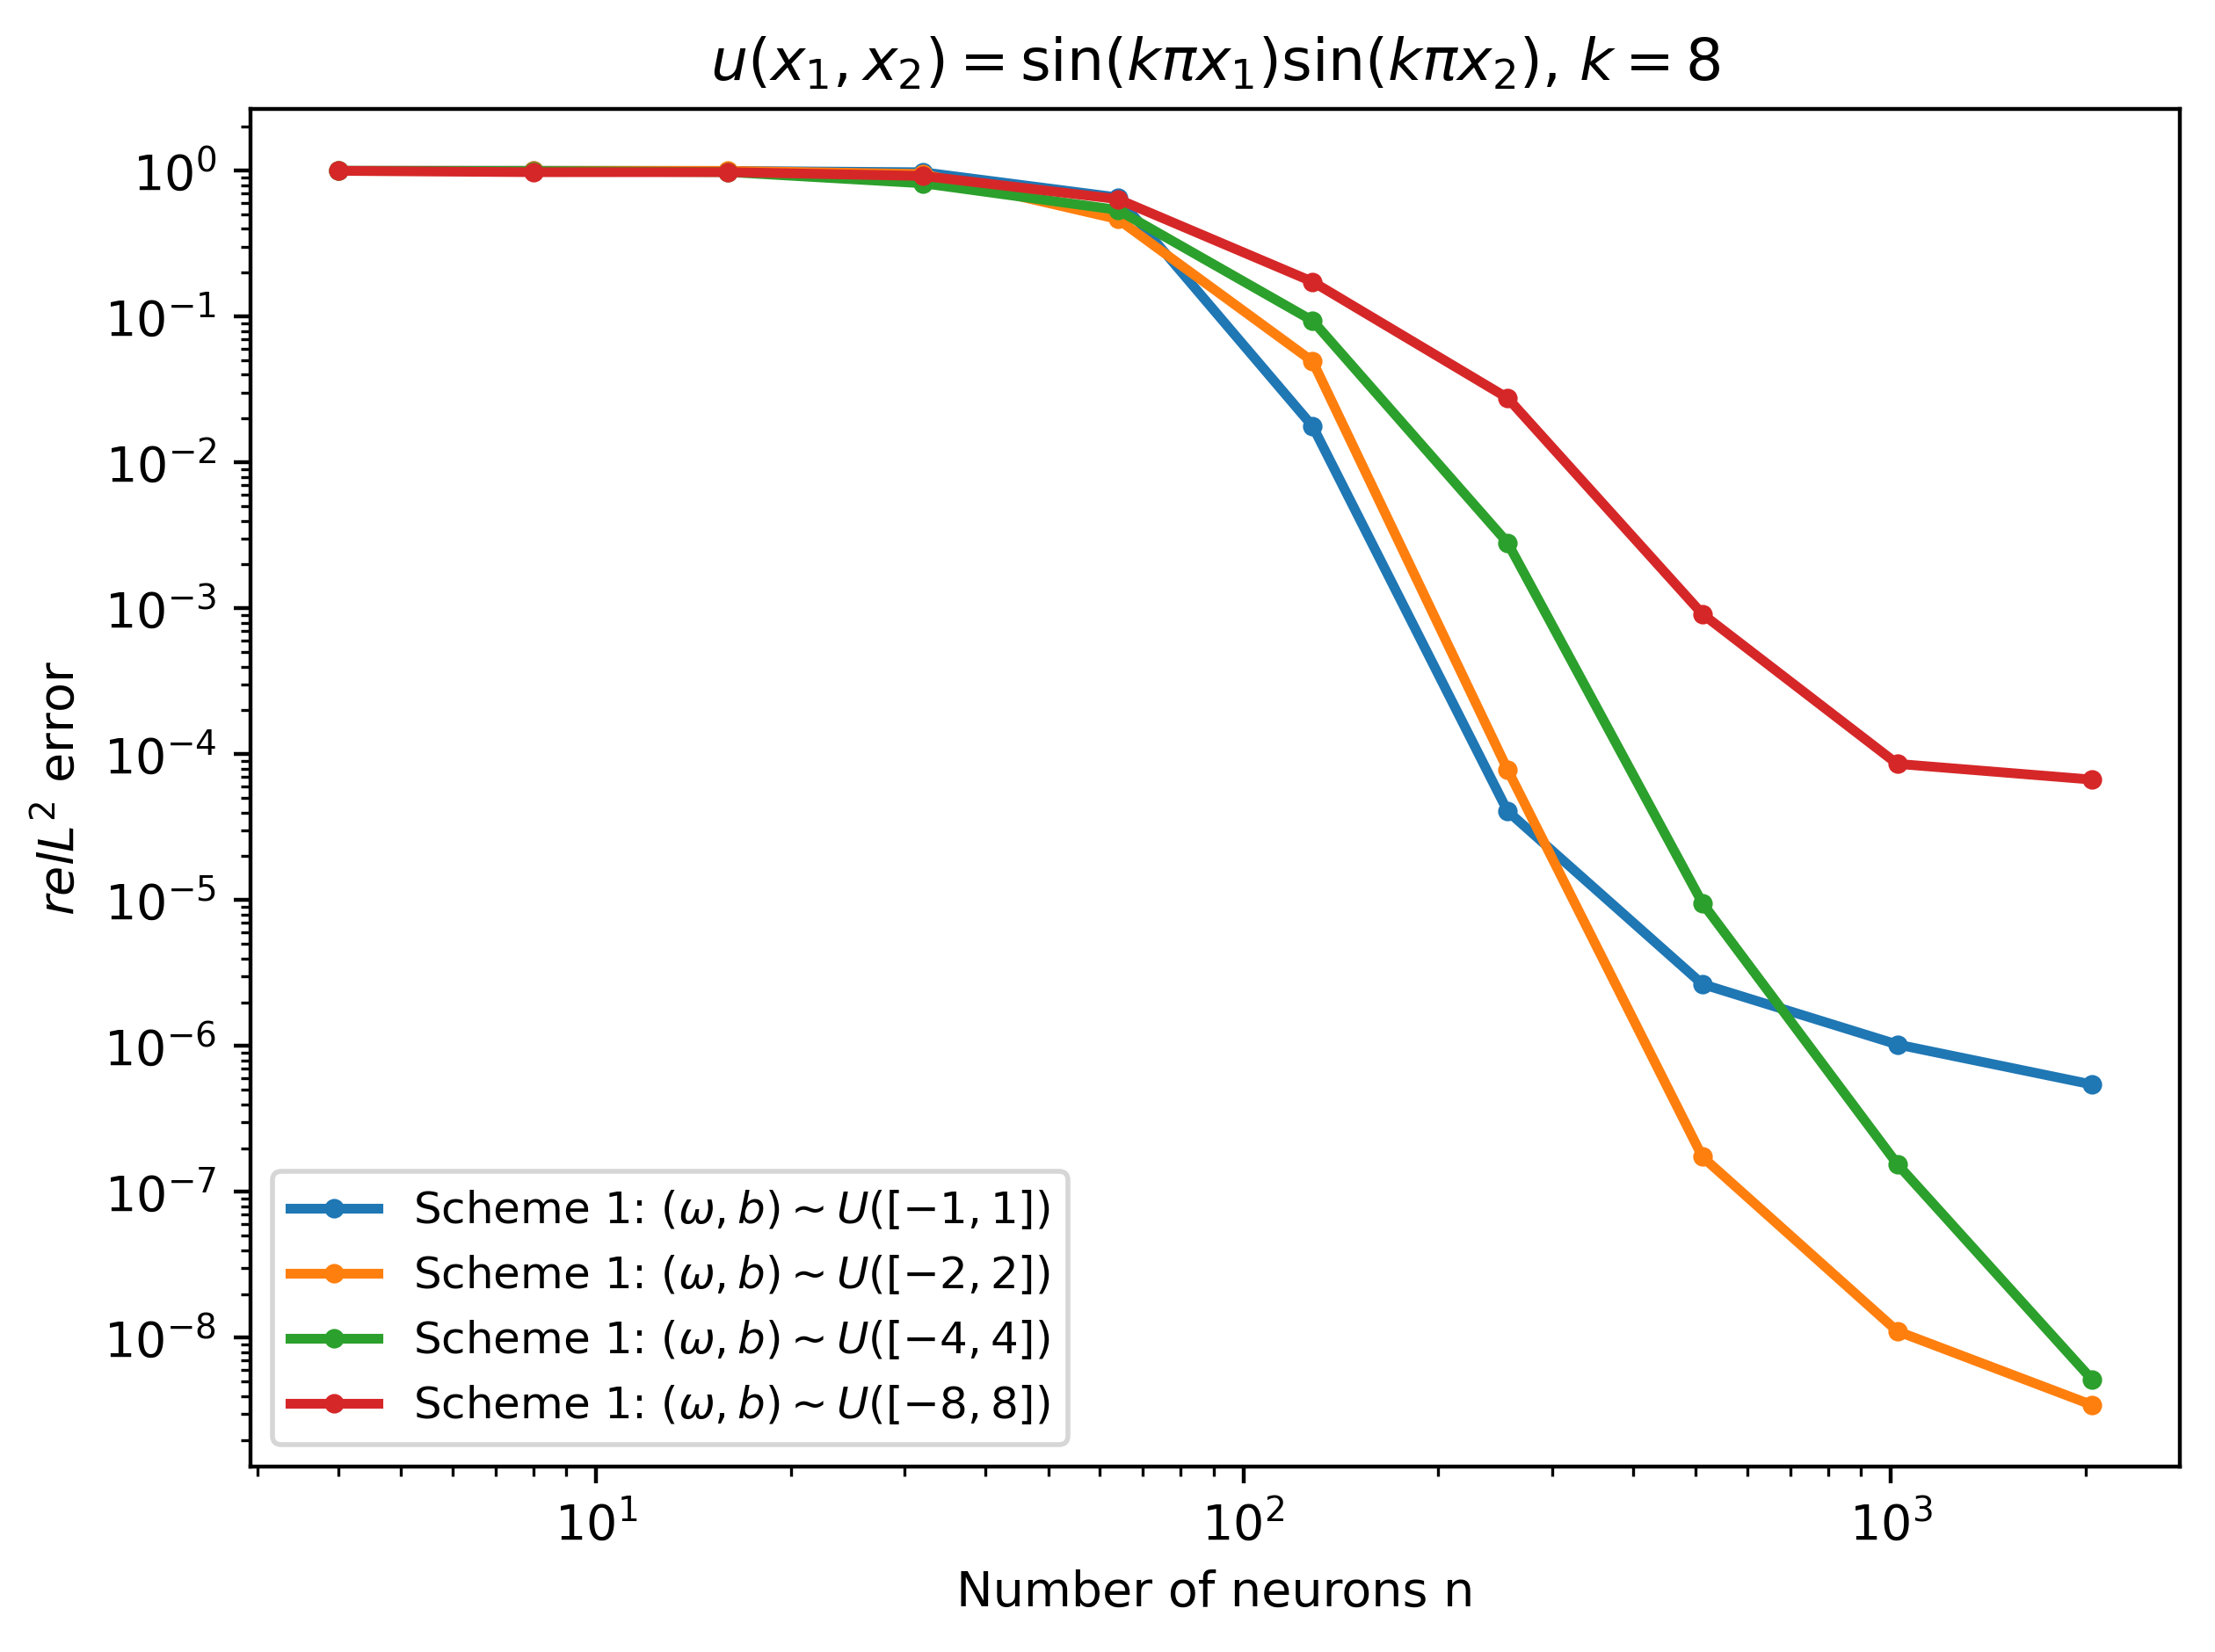

In [8]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 8 
def target(x):
    z =  torch.sin(k*x[:,0:1])*torch.sin(k*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,50)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [1,2,4,8]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    # plt.figure(dpi = 400)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    # log_M = np.log(neuron_num_arr)
    # log_errors = np.log(mean_err_l2_arr)
    # slope, intercept = np.polyfit(log_M, log_errors, 1)
    # def line_of_best_fit(x):
    #     return np.exp(intercept) * (x ** slope)
    # best_fit = line_of_best_fit(neuron_num_arr)
    # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

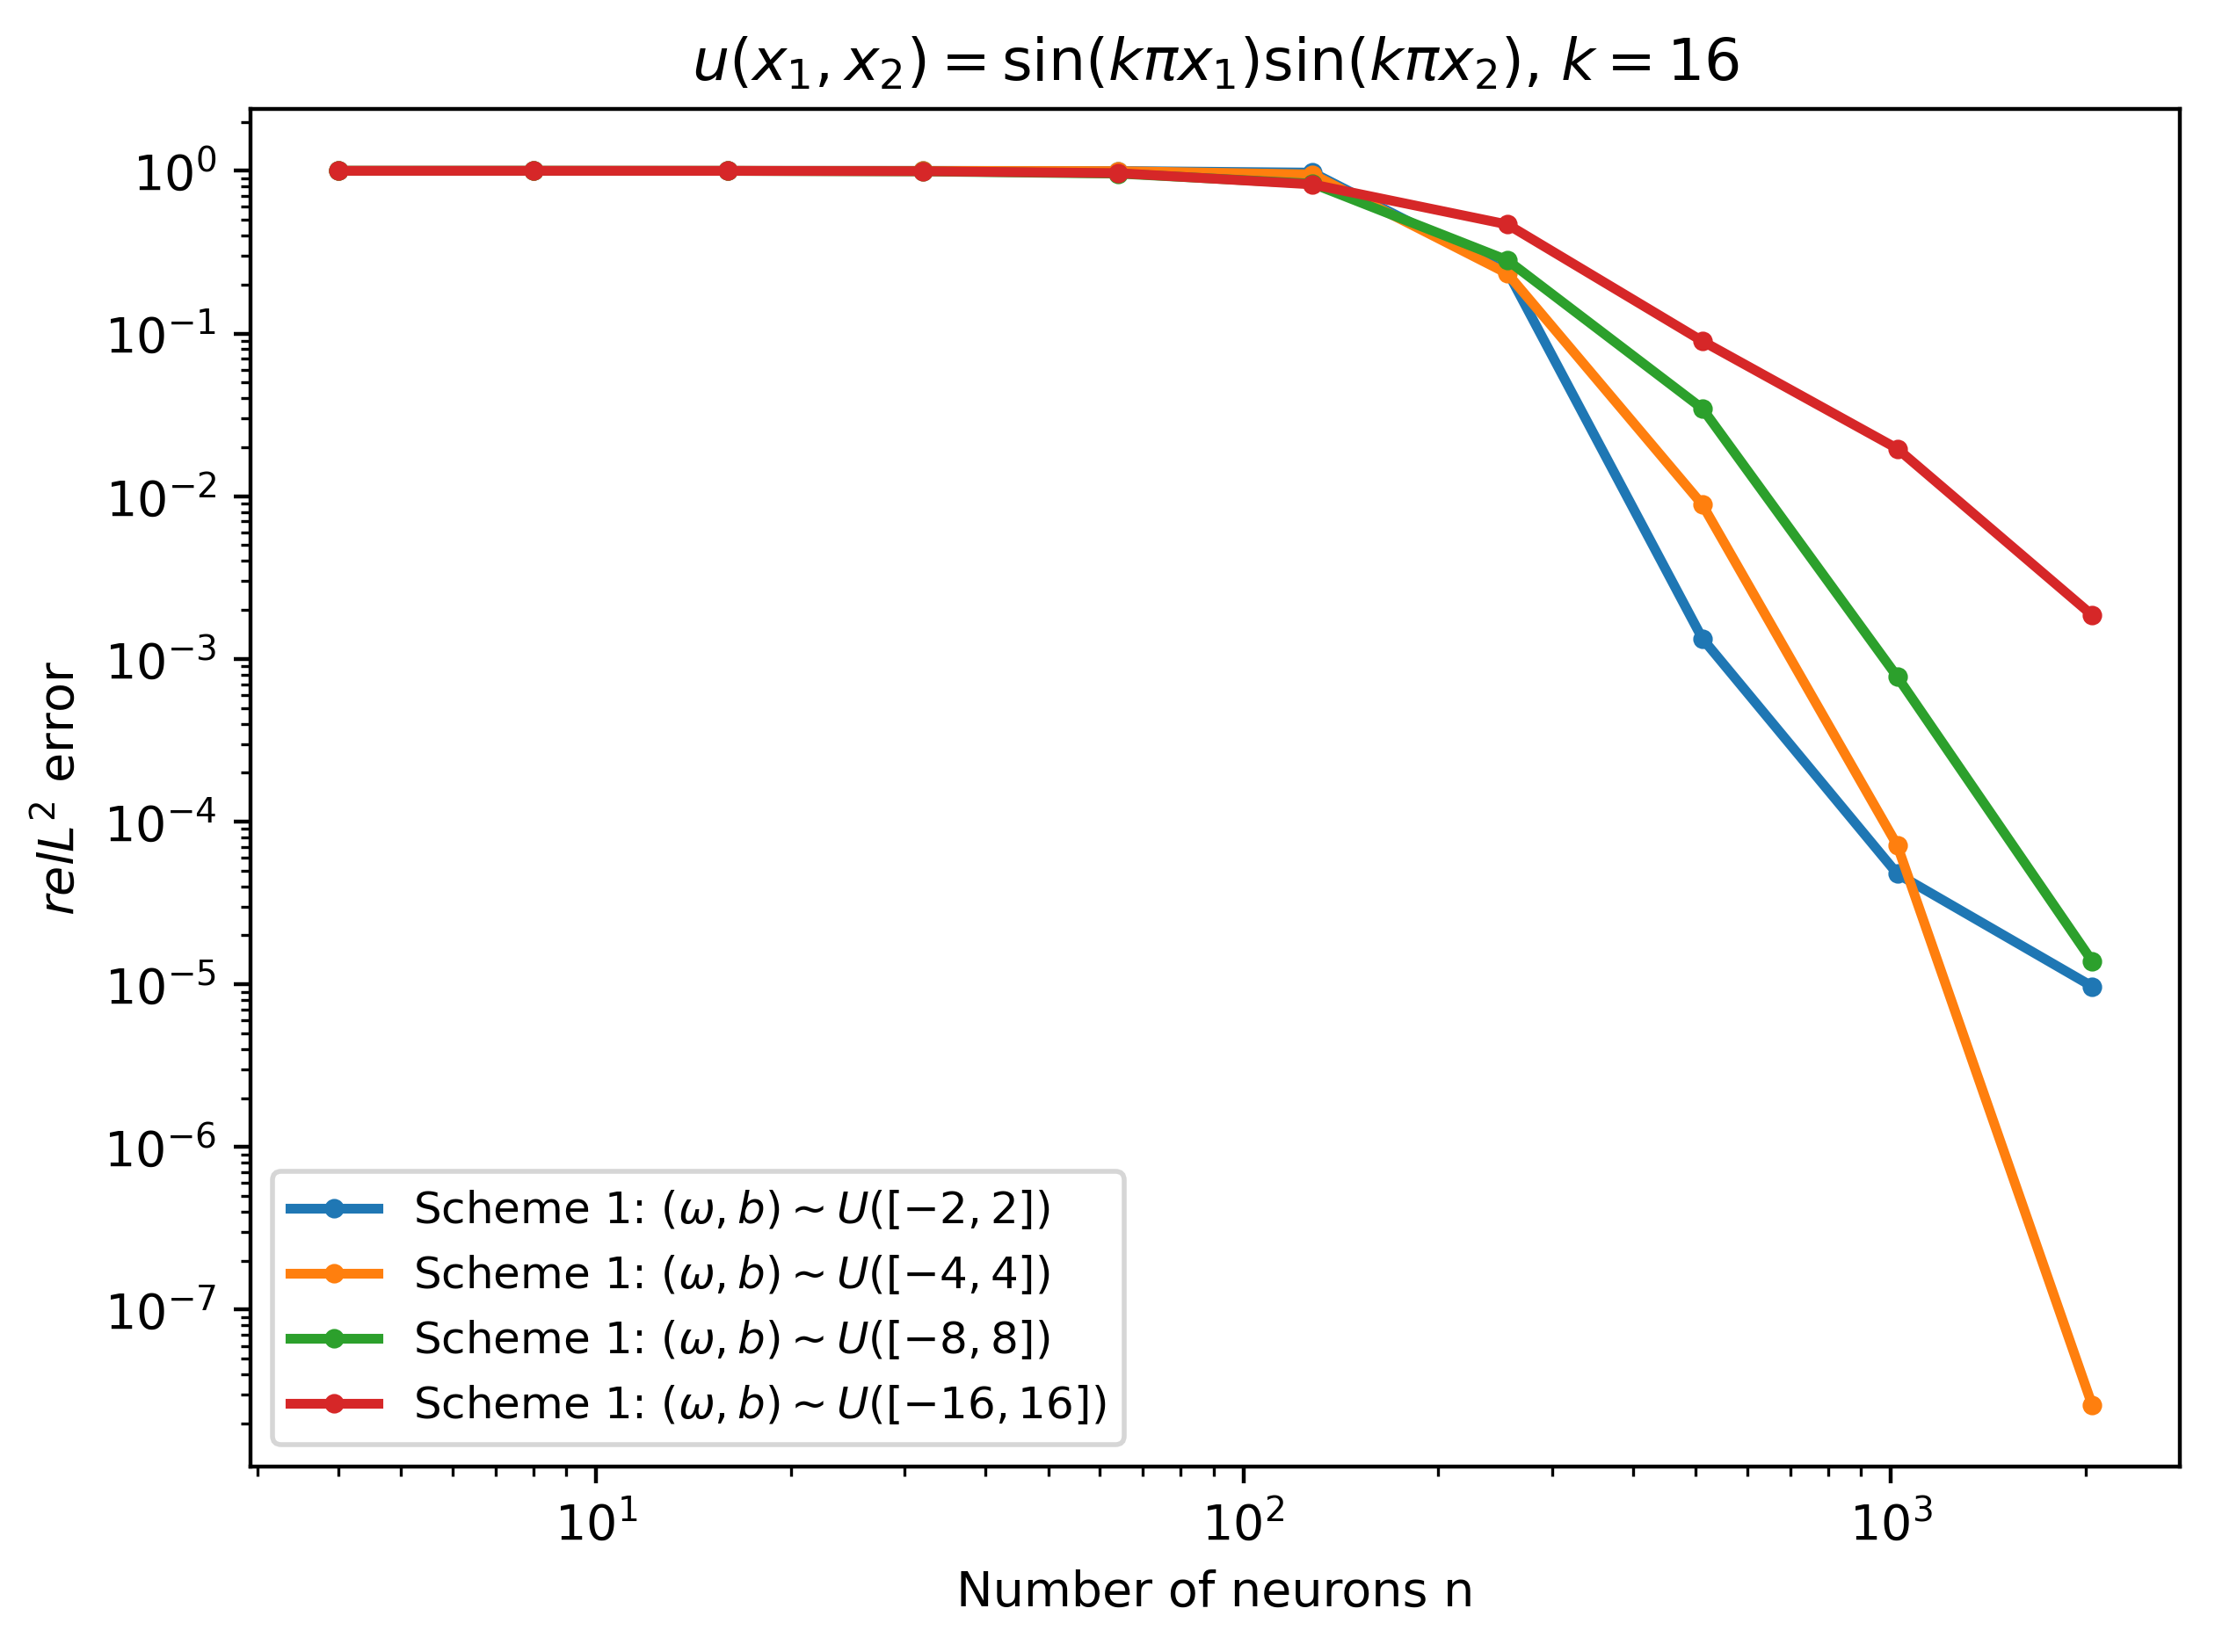

In [15]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 16 
def target(x):
    z =  torch.sin(k*x[:,0:1])*torch.sin(k*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [2,4,8,16]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    # plt.figure(dpi = 400)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

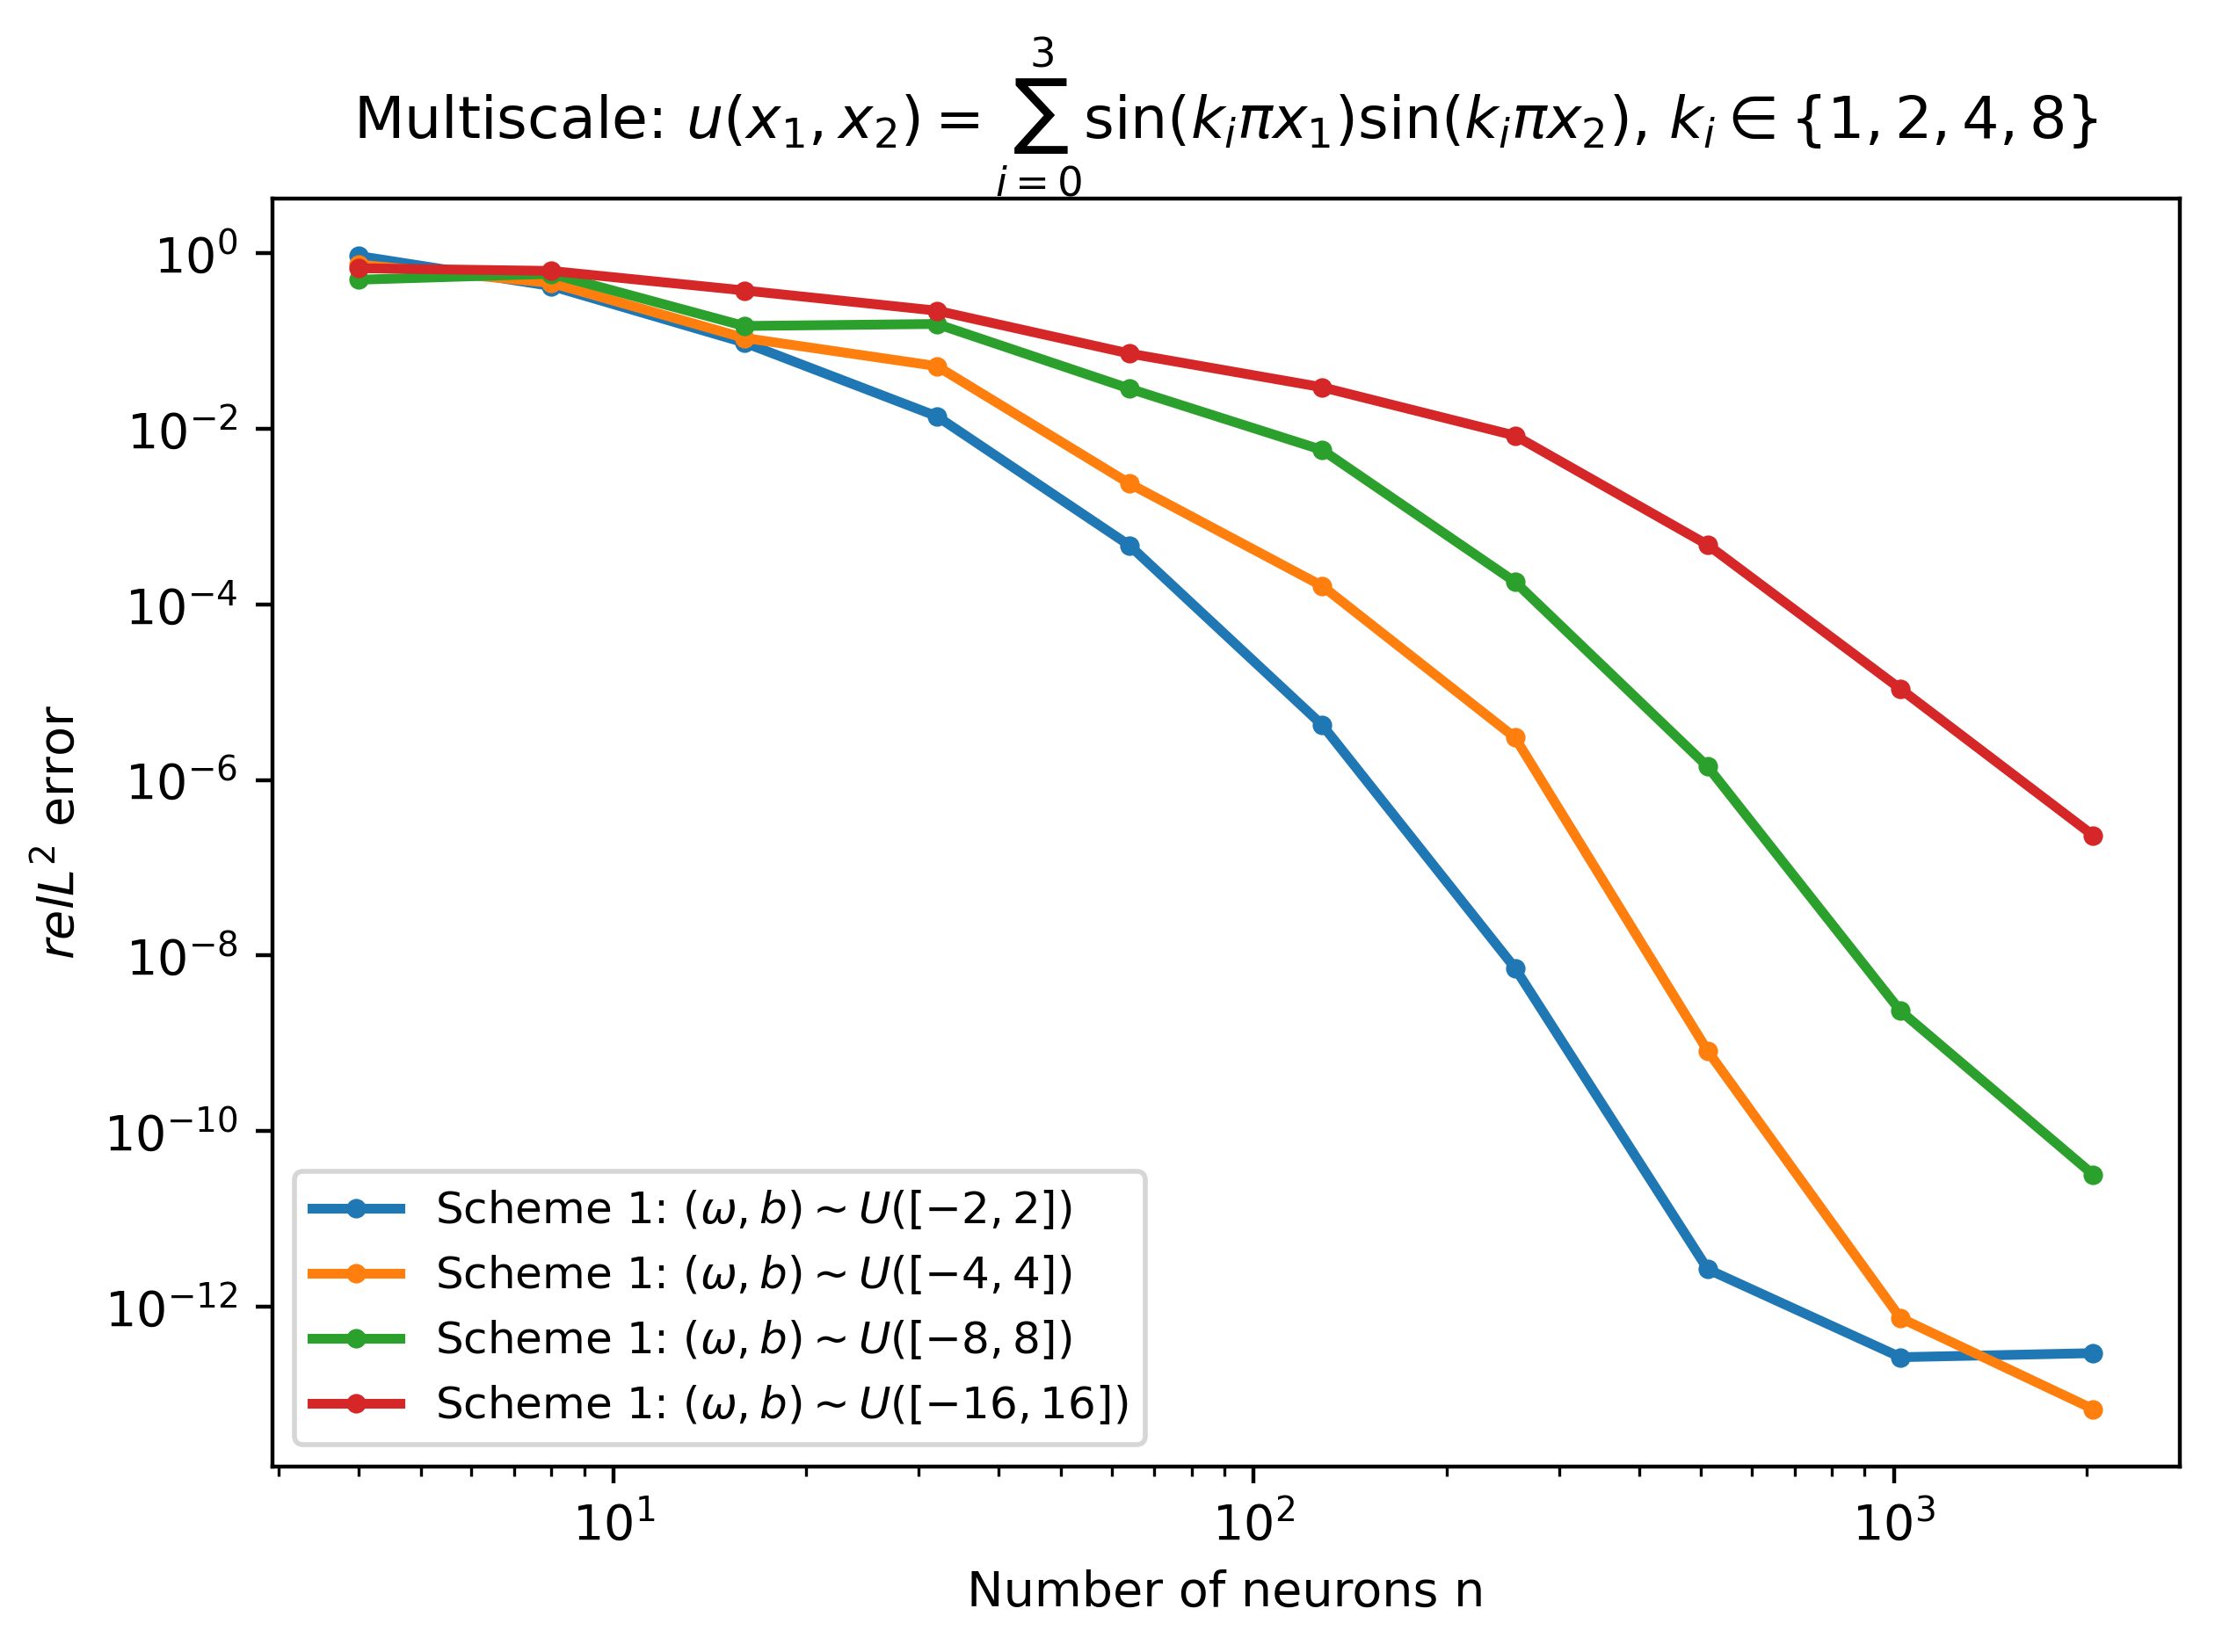

In [25]:
## multiscale solution 
k0 = 1 
k1 = 2
k2 = 4
k3 = 8

def target(x):
    z =  torch.sin(k0*x[:,0:1])*torch.sin(k0*x[:,1:2] ) + torch.sin(k1*x[:,0:1])*torch.sin(k1*x[:,1:2] ) 
    + torch.sin(k2*x[:,0:1])*torch.sin(k2*x[:,1:2] ) + torch.sin(k3*x[:,0:1])*torch.sin(k3*x[:,1:2] )
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [2,4,8,16]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "Multiscale: $u(x_1,x_2) = \sum_{i = 0}^3 \sin(k_i\pi x_1) \sin(k_i \pi x_2)$, $k_i \in \{1,2,4,8\}$" 
    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

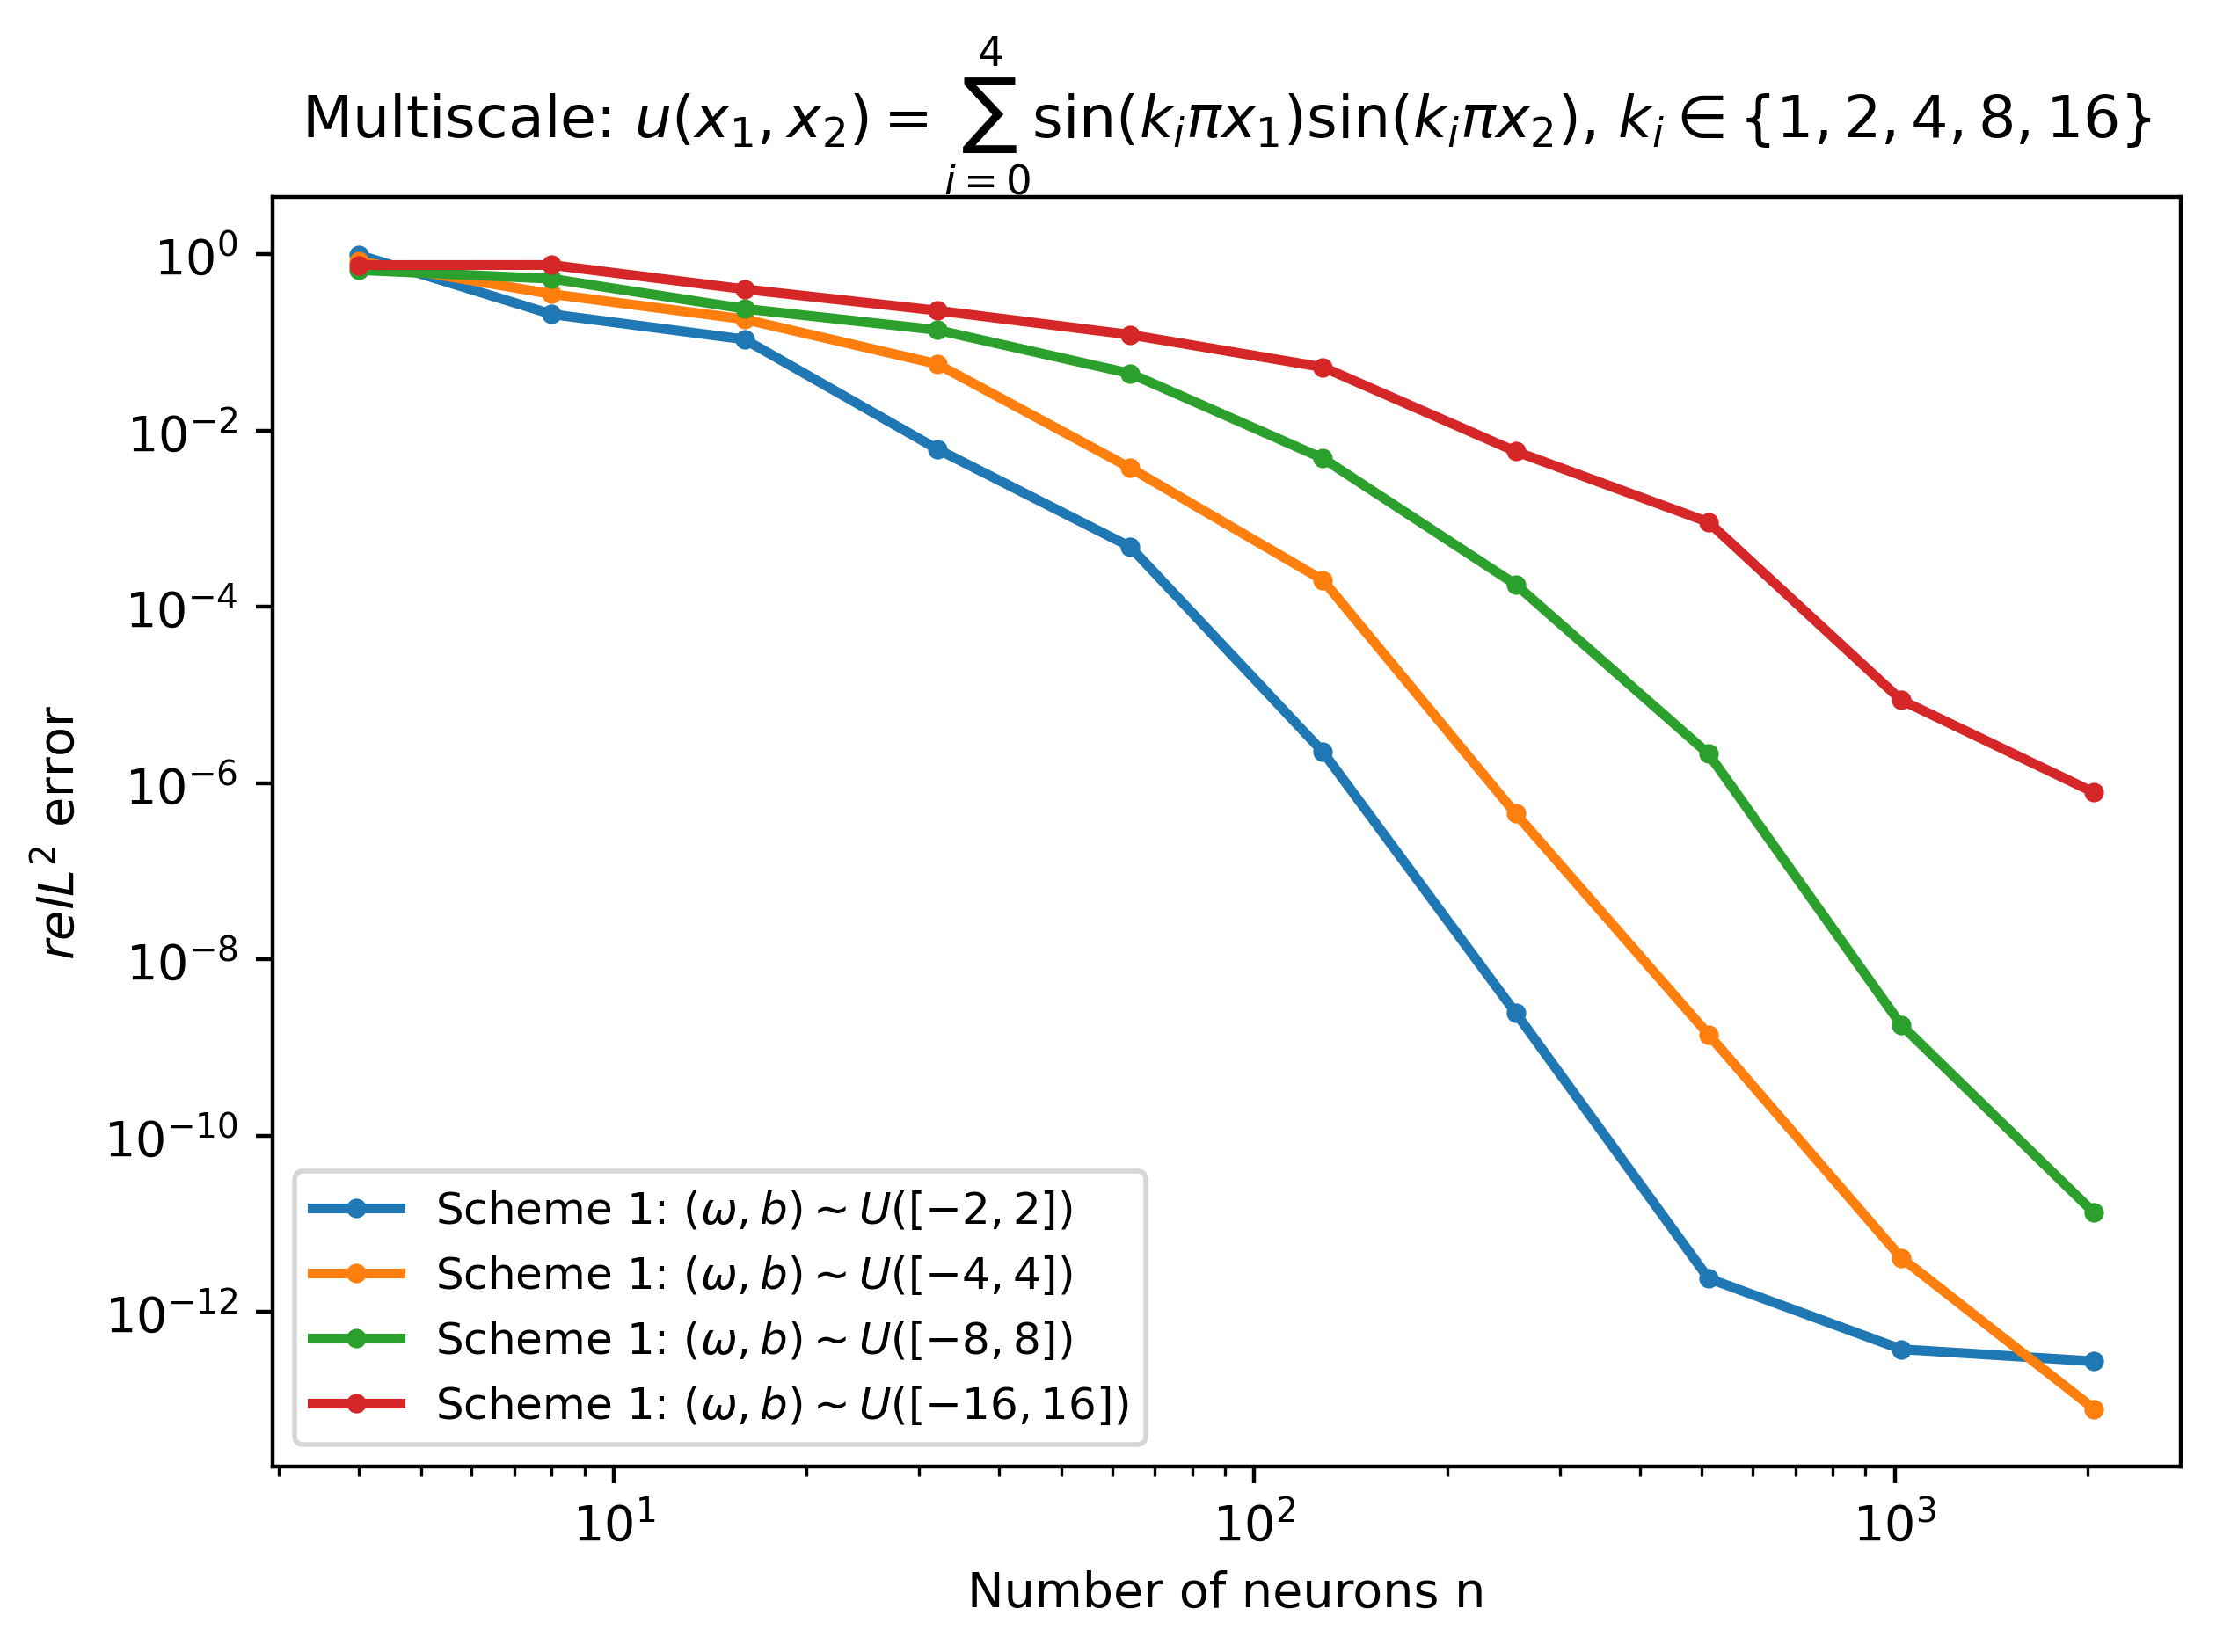

In [26]:
## multiscale solution 
k0 = 1 
k1 = 2
k2 = 4
k3 = 8
k4 = 16 

def target(x):
    z =  torch.sin(k0*x[:,0:1])*torch.sin(k0*x[:,1:2] ) + torch.sin(k1*x[:,0:1])*torch.sin(k1*x[:,1:2] ) 
    + torch.sin(k2*x[:,0:1])*torch.sin(k2*x[:,1:2] ) + torch.sin(k3*x[:,0:1])*torch.sin(k3*x[:,1:2] )
    + torch.sin(k4*x[:,0:1])*torch.sin(k4*x[:,1:2] )
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [2,4,8,16]
# plt.rcParams.update({'font.size': 20})
# fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
fig = plt.figure(dpi =400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)

            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            # with torch.no_grad(): 
            #     nn_func_values = my_model(integration_points_test) 
            # target_values = target(integration_points_test) 
            # diff_sqrd = (nn_func_values - target_values)**2 
            # err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            # err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)


    legend1 = "Scheme 1: $(\omega,b) \sim U([-{}, {}])$".format(R_m,R_m)
    title = "Multiscale: $u(x_1,x_2) = \sum_{i = 0}^4 \sin(k_i\pi x_1) \sin(k_i \pi x_2)$, $k_i \in \{1,2,4,8,16\}$" 
    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize=9)
    plt.ylabel("$rel L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

## 2D scheme 2 

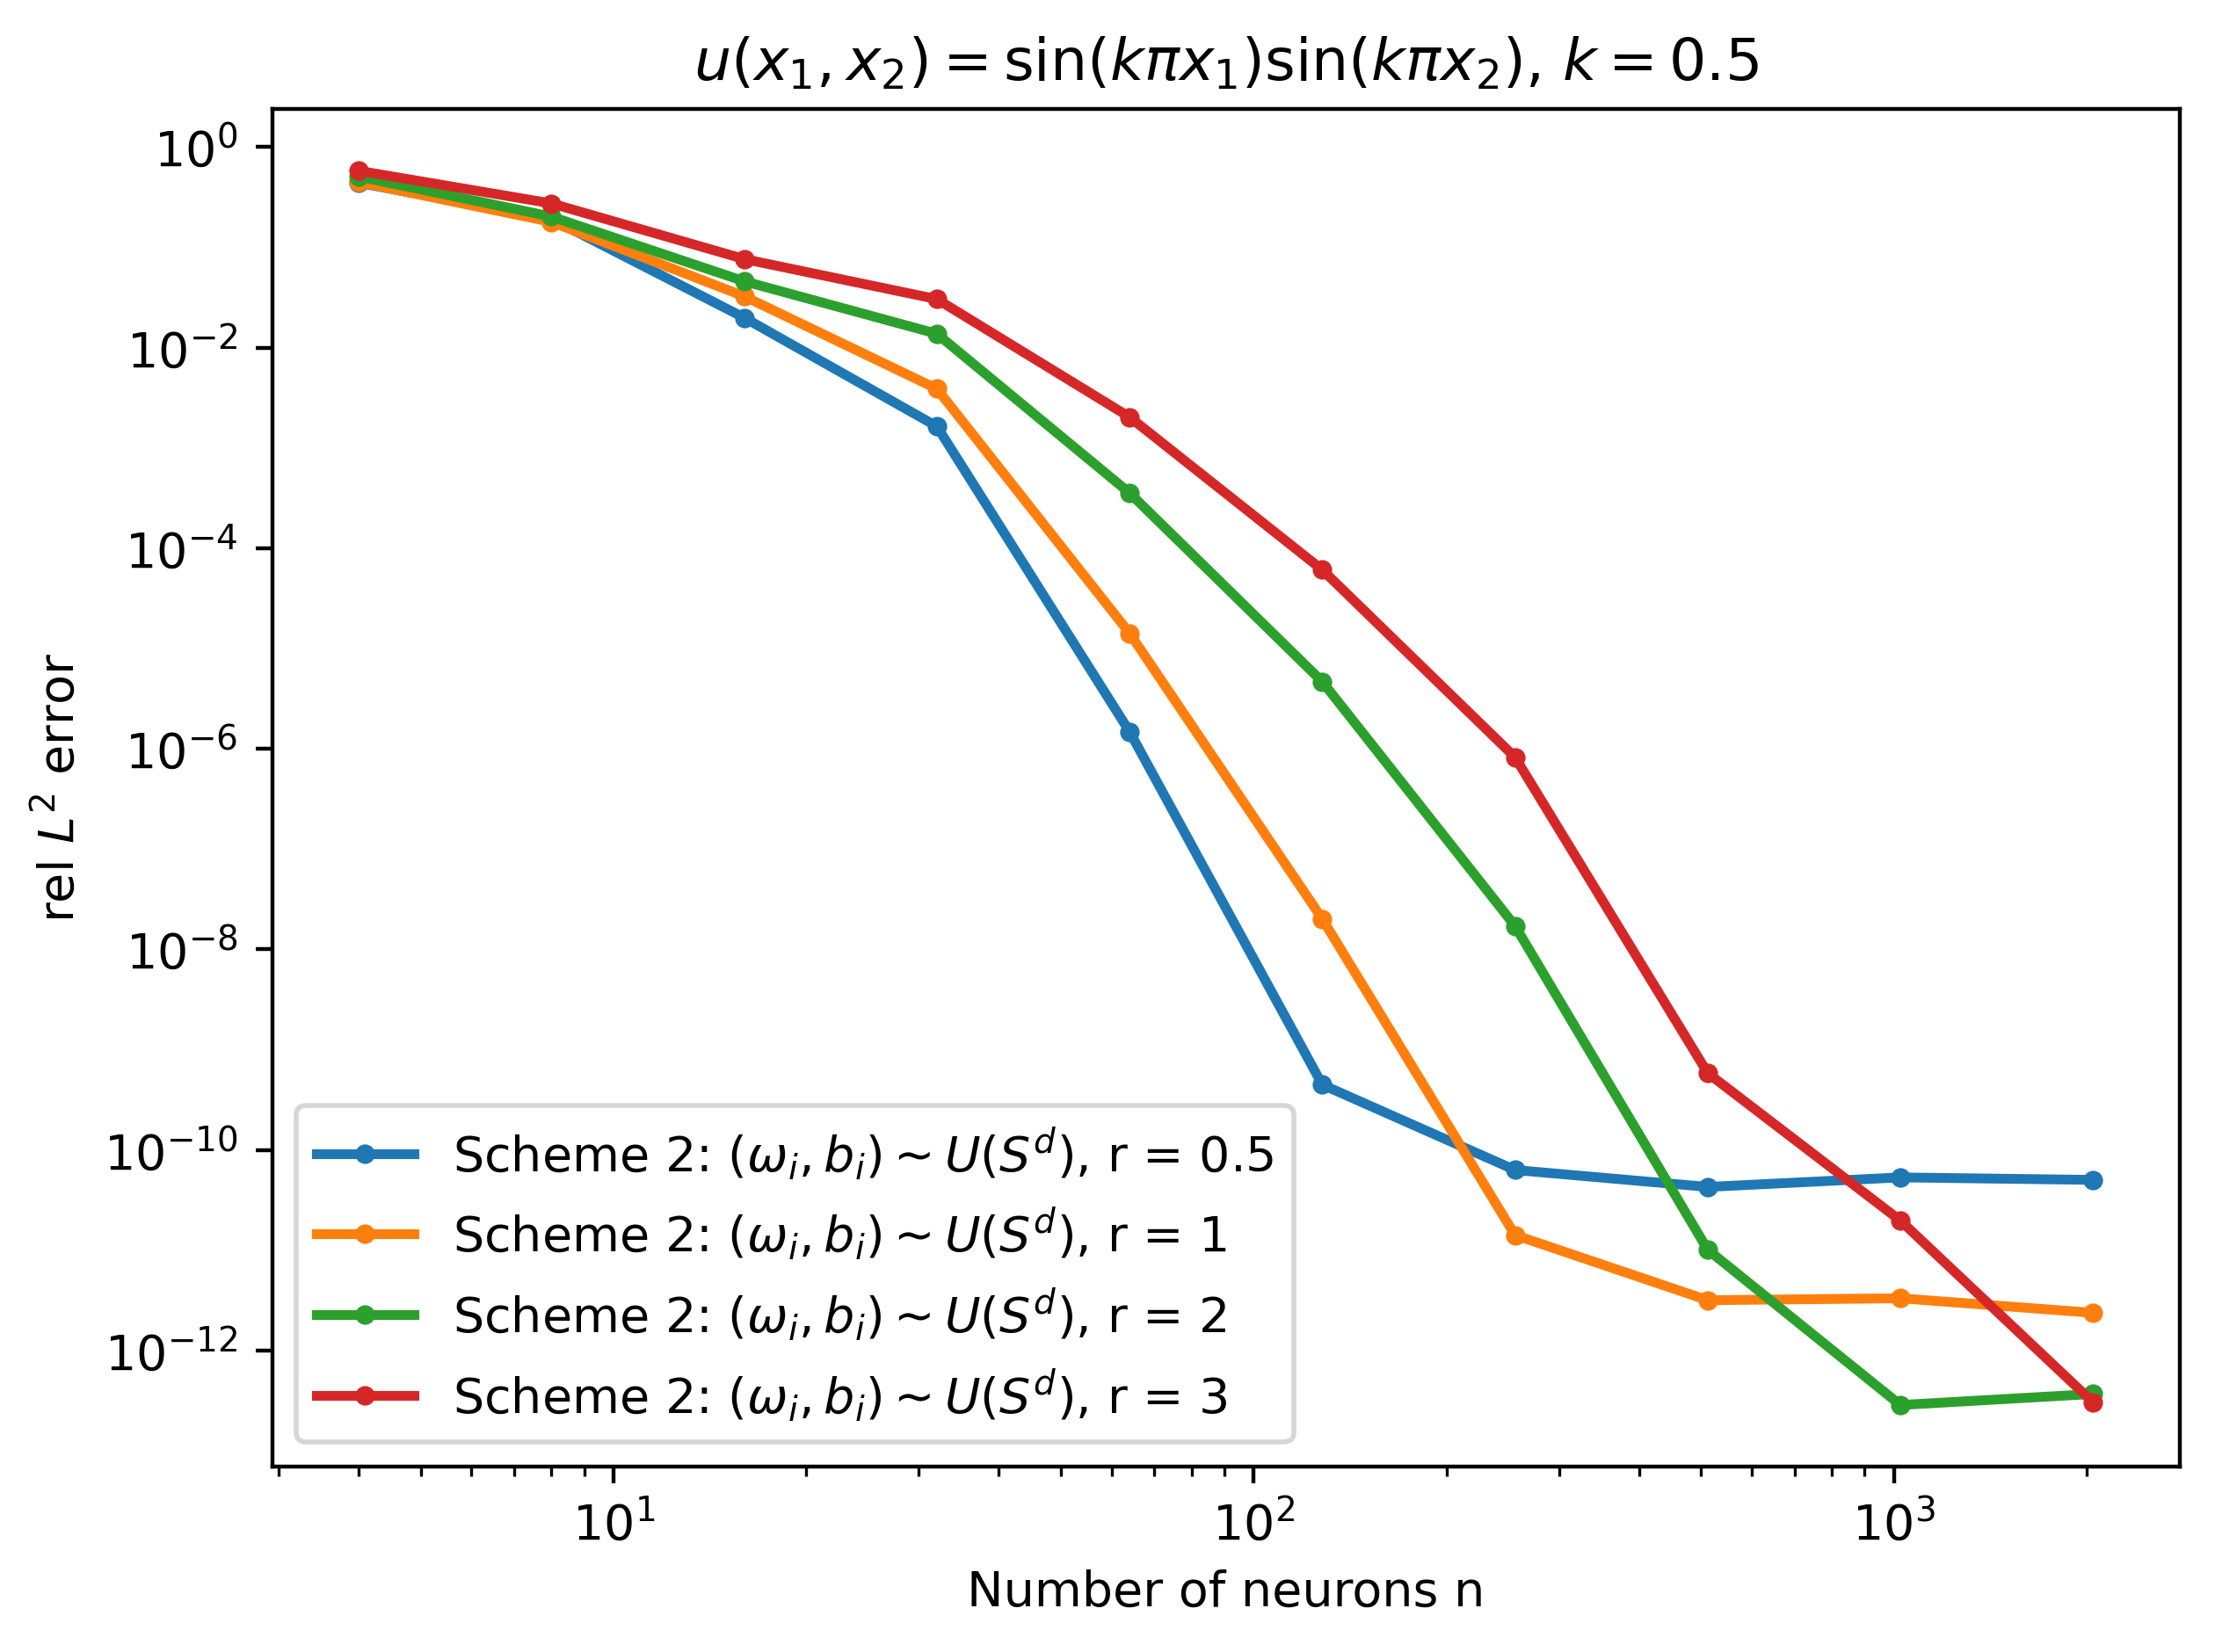

In [ ]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 0.5  
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,50)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [0.5,1,2,3]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 

            my_model = initialize_w_b_sphere(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

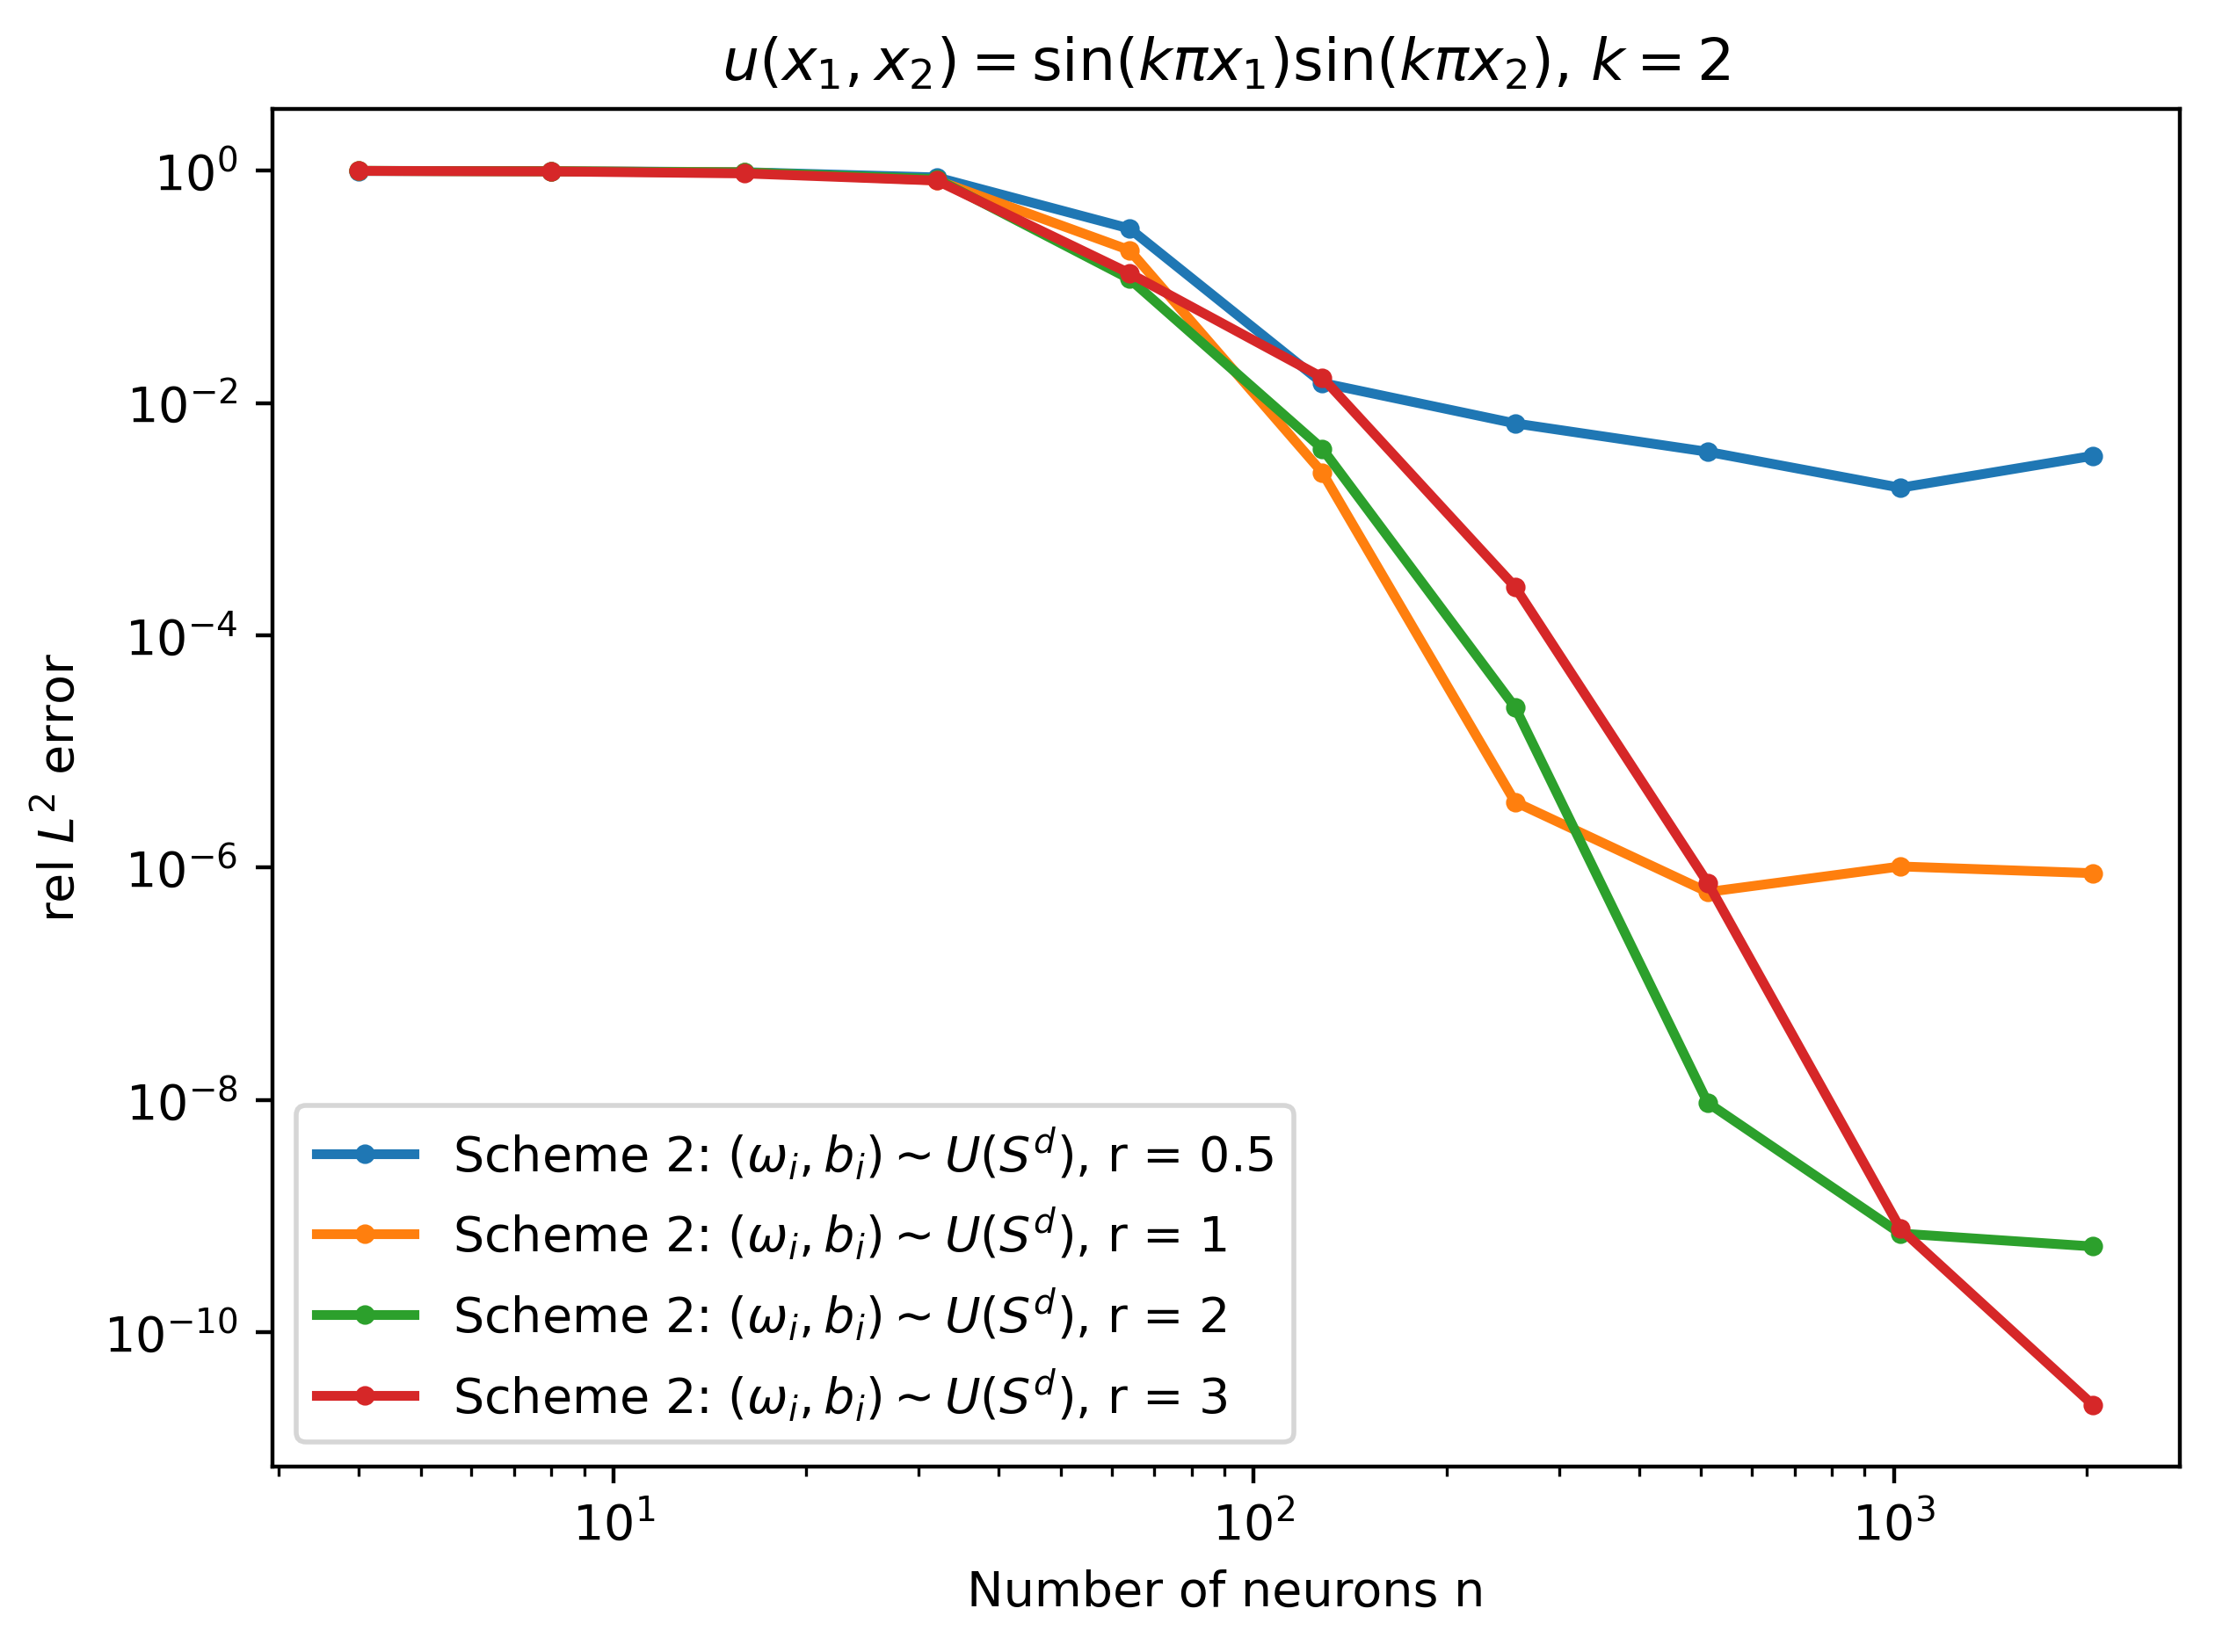

In [ ]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 2 
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z


Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)


save = False 
R_m_list = [0.5,1,2,3]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            my_model = initialize_w_b_sphere(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

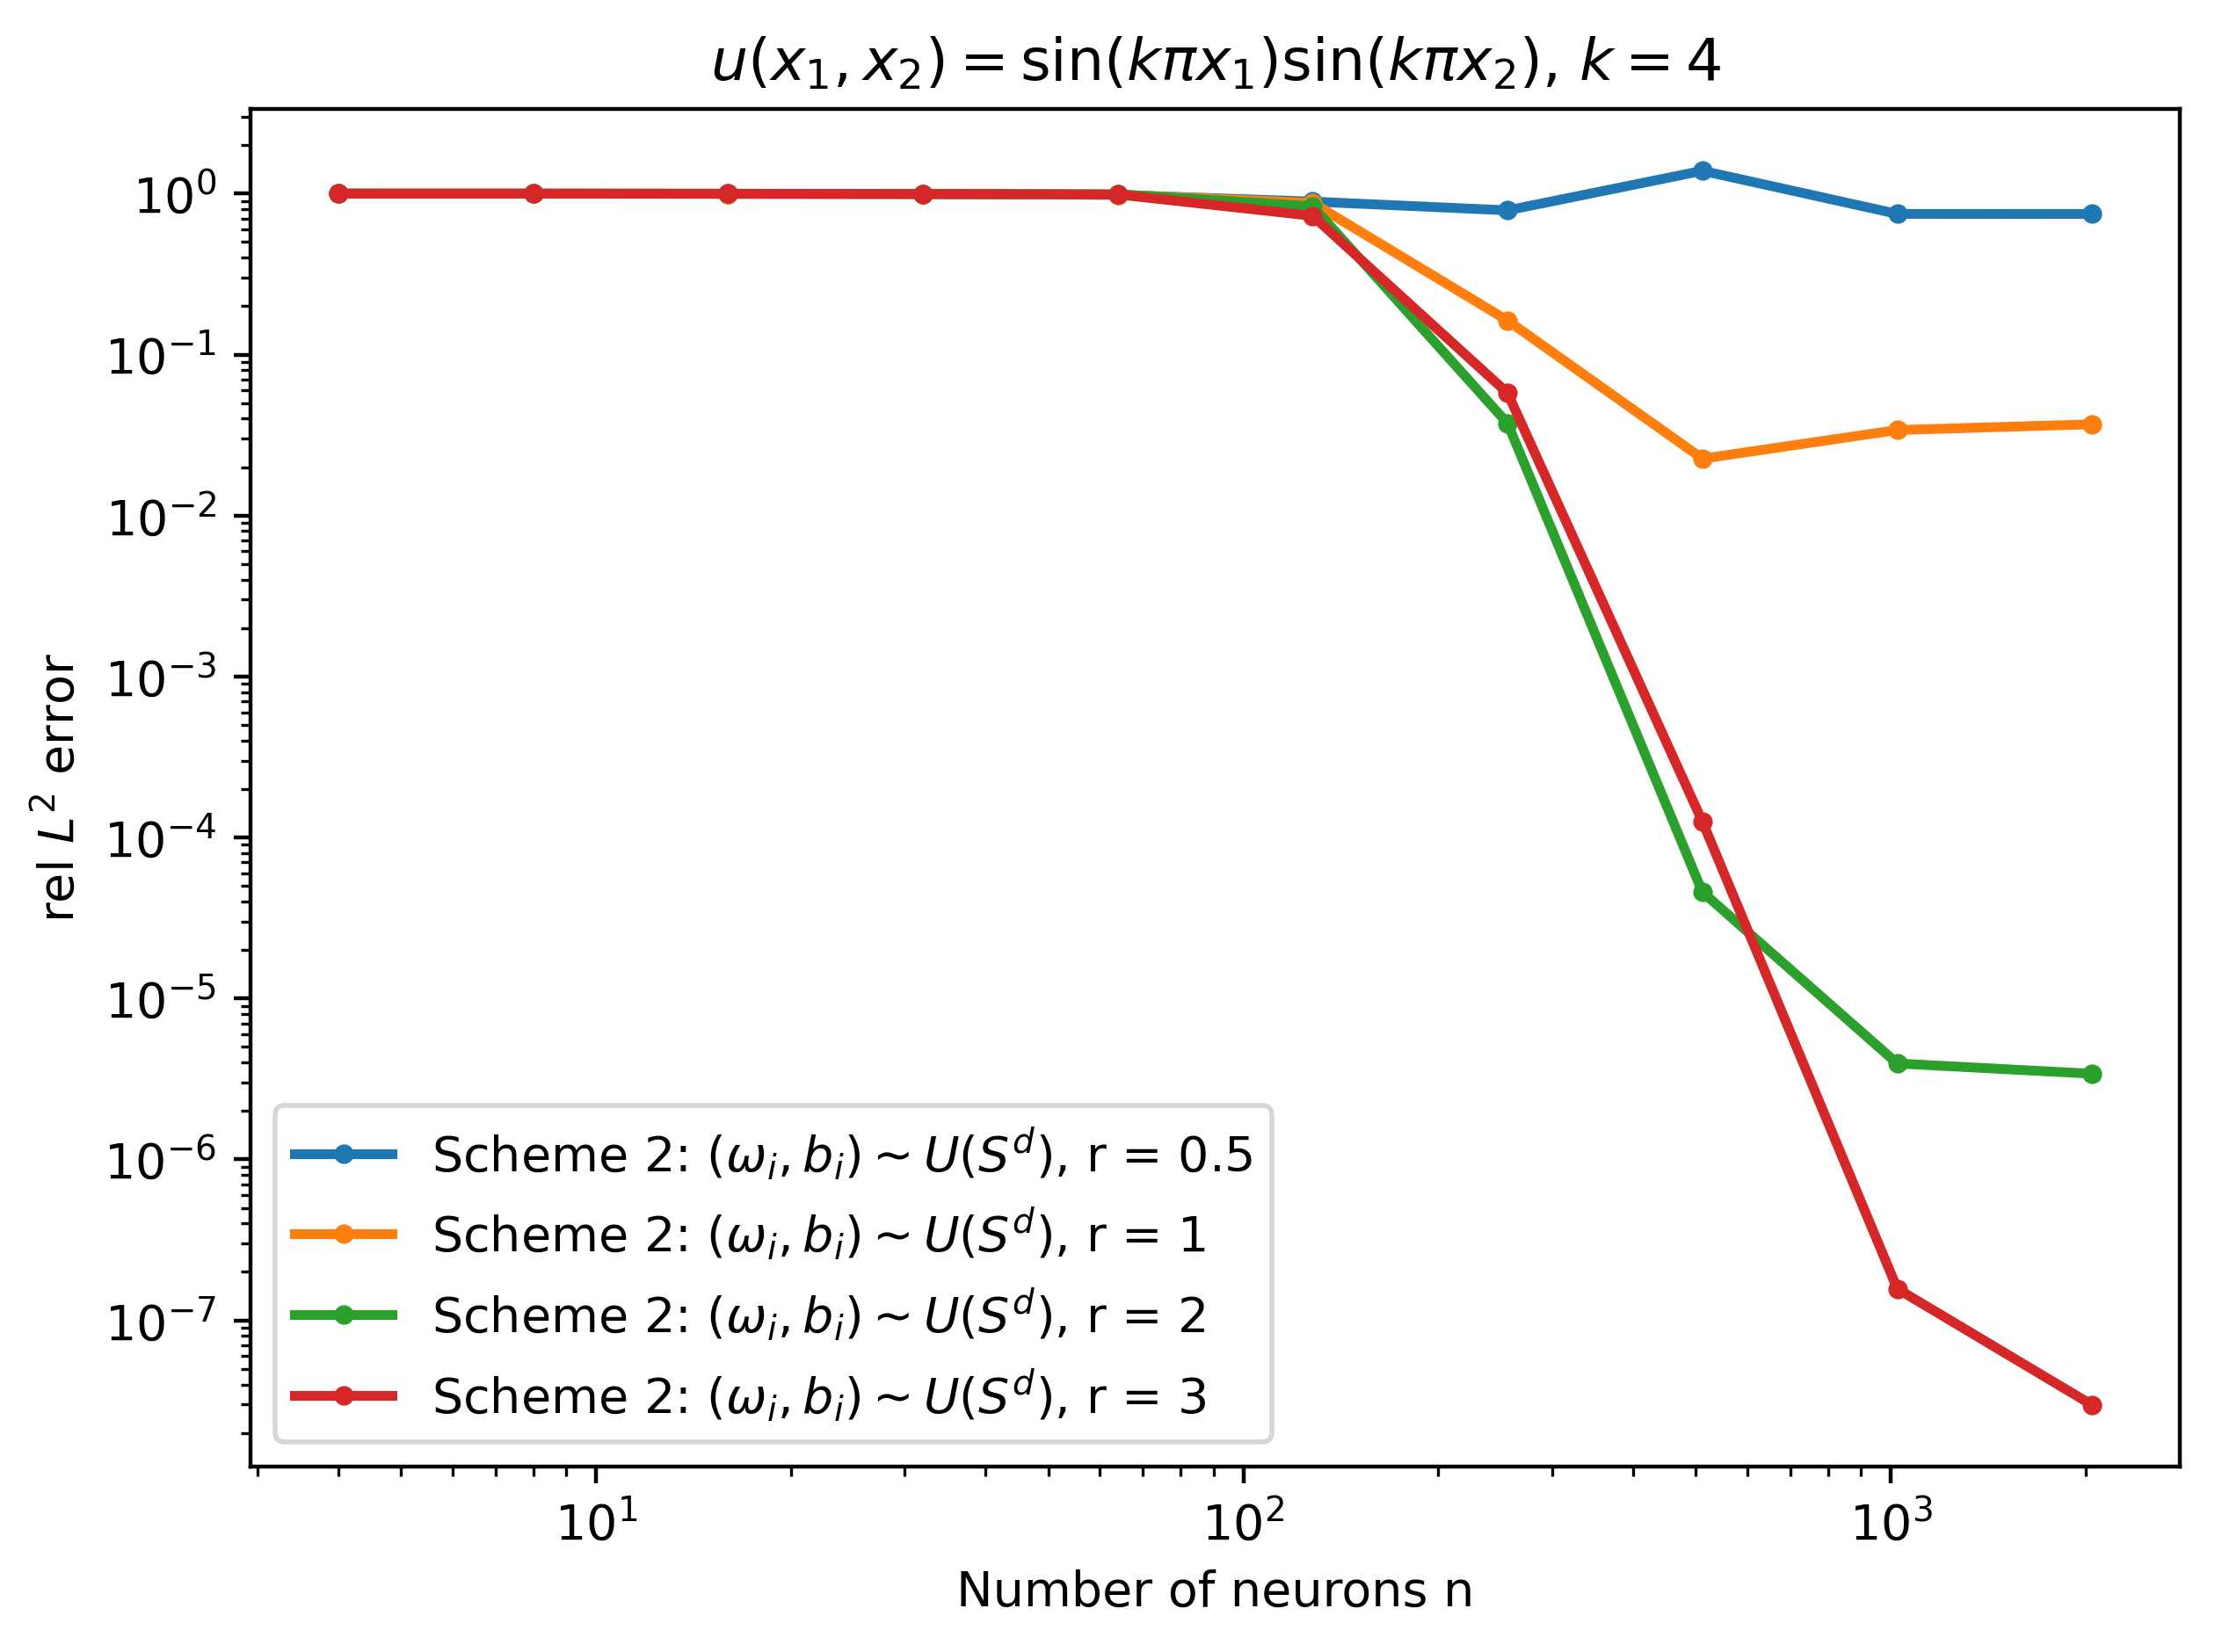

In [16]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 4 
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z


Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

save = False 
R_m_list = [0.5,1,2,3]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            my_model = initialize_w_b_sphere(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

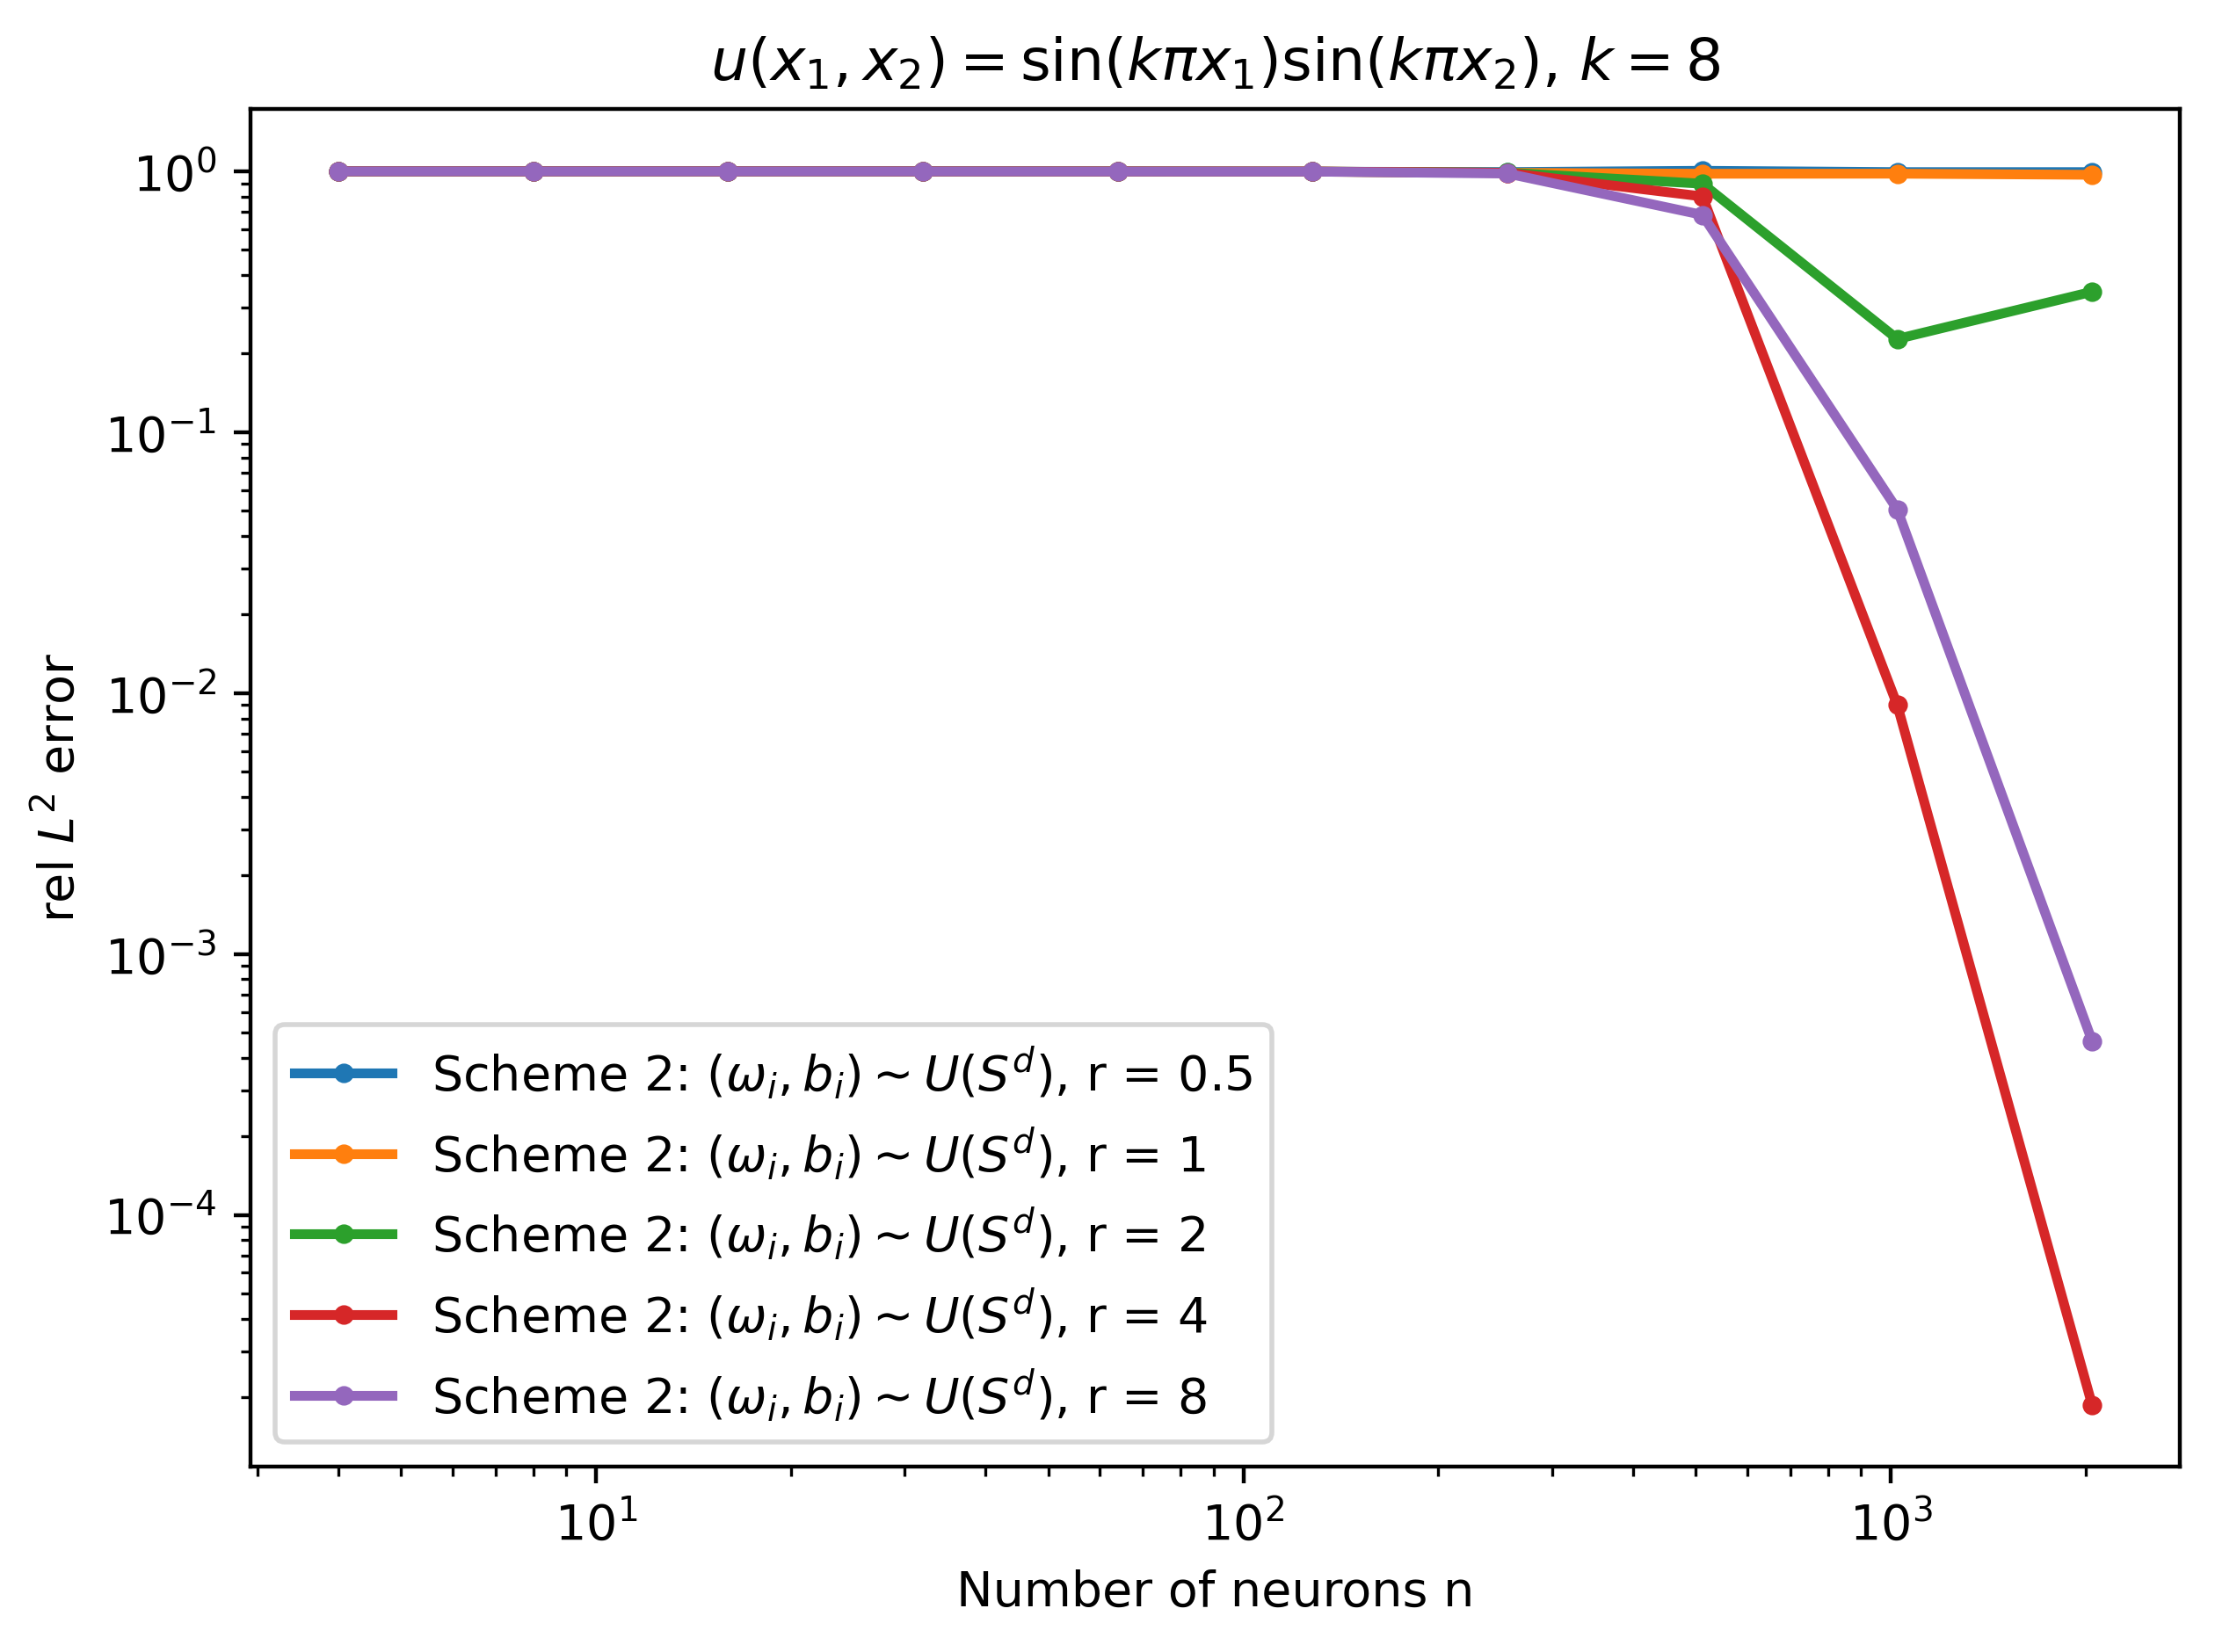

In [18]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 8 
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z


Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

save = False 
R_m_list = [0.5,1,2,4,8]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            my_model = initialize_w_b_sphere(my_model,R_m) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

## 2D scheme 3

/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_54706/3763127175.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta).to(device)
/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_54706/3763127175.py:127: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  biases = torch.tensor(biases).to(device)


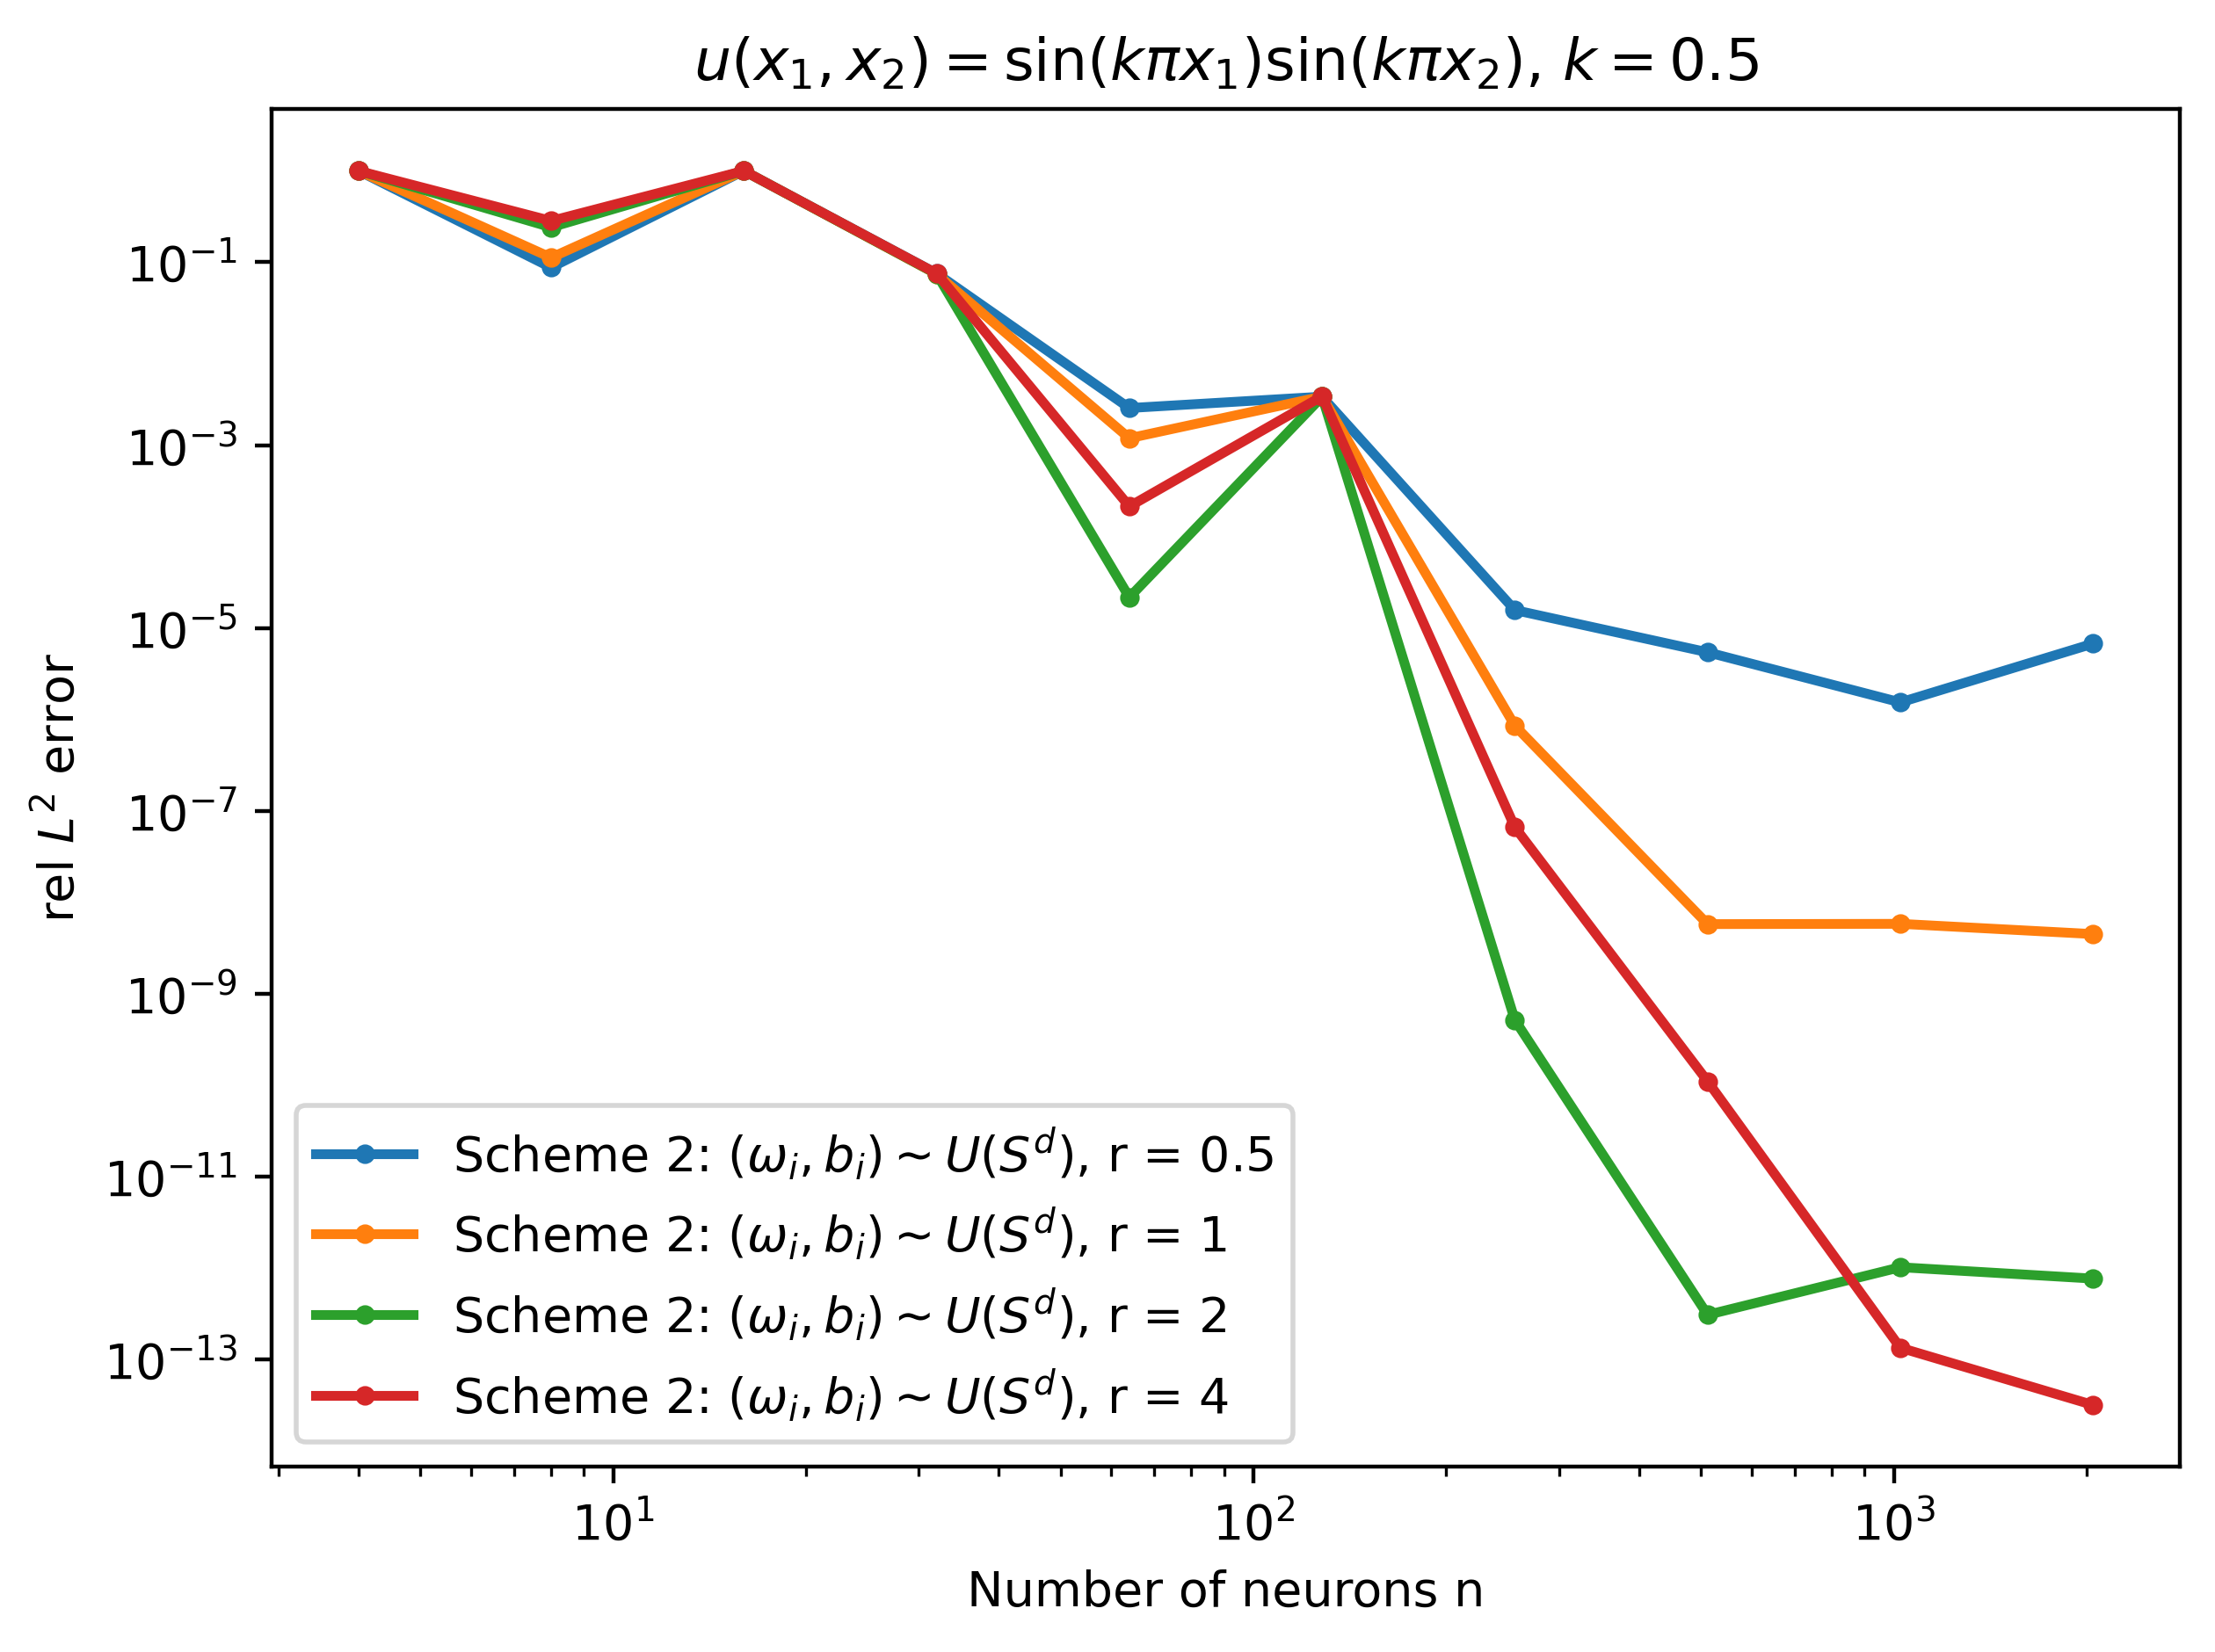

In [20]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 0.5 
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

save = False 
R_m_list = [0.5,1,2,4]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_b_sphere(my_model,R_m) 
            my_model = initialize_w_b_petrushev(my_model,R_m)
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()

/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_54706/3763127175.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta).to(device)
/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_54706/3763127175.py:127: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  biases = torch.tensor(biases).to(device)


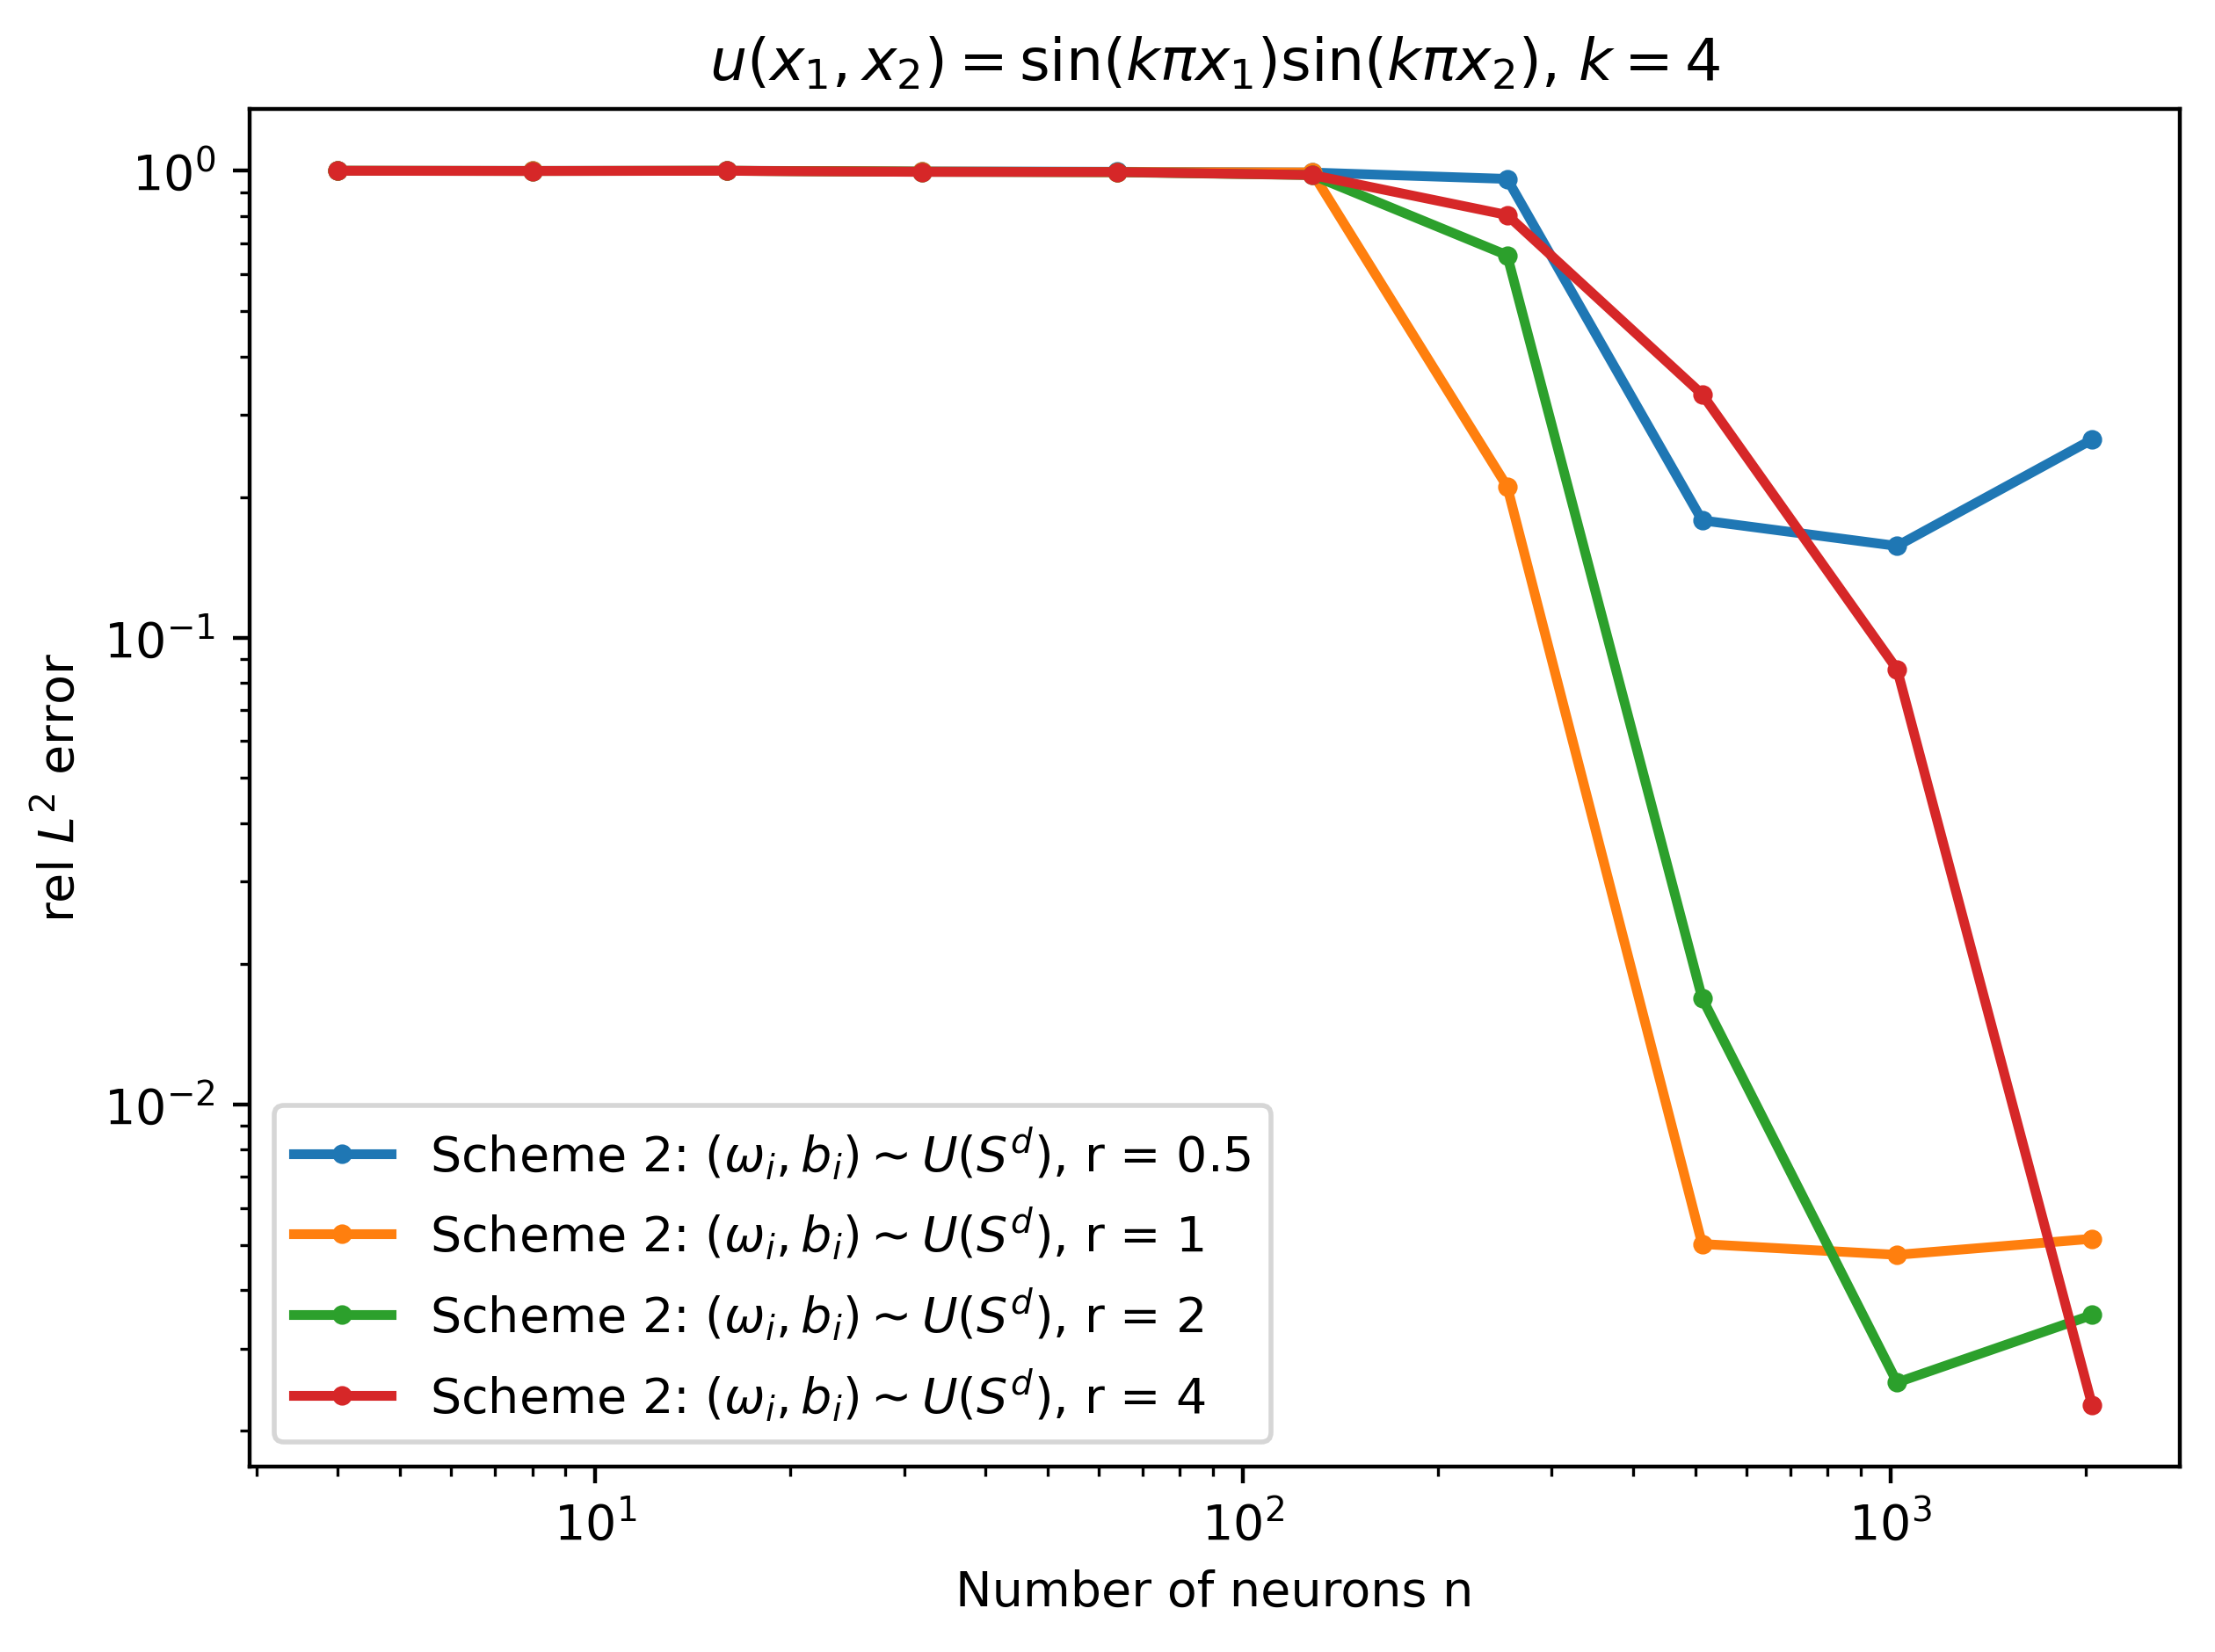

In [22]:

##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
k = 4 
def target(x):
    z = torch.sin(k * pi*x[:,0:1])*torch.sin( k*pi*x[:,1:2] )   
    return z

Nx = 20   
order = 3 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(40, order,[-1,-1],[1,1])

x = torch.linspace(-1,1,100)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,200)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

save = False 
R_m_list = [0.5,1,2,4]
fig = plt.figure(dpi =400) 
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,12)]) 
    for n in neuron_num_arr : 
        trial_num = 1 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(2, n, 1).to(device) 
            # my_model = initialize_w_b_sphere(my_model,R_m) 
            my_model = initialize_w_b_petrushev(my_model,R_m)
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 
    
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)

    title = "$u(x_1,x_2) = \sin(k\pi x_1) \sin(k\pi x_2)$, $k = {}$".format(k)
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(S^d)$, r = {}".format(R_m)

    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)

    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)

plt.tight_layout()
plt.show()